1. Derive the retention table first (the foundation)

Join activity_log → users on user_id
Compute week_since_signup = (workout_logged_date - signup_date).days // 7
Collapse to a boolean: was the user active at all in week N (since a user can have multiple workout logs in one week)
Decide and document your week-bucketing convention (e.g., does week 0 = signup week, or does week 1 start the day after signup?) — this exact ambiguity is a common "gotcha" in SQL retention interview questions

2. N-day vs. rolling retention, by channel

N-day: % active in exactly week N
Rolling: % active in week N or any week after
Compare the two — rolling will always be ≥ N-day; if it isn't, you have a bug
This is the core deliverable — practice explaining when you'd use each (N-day for "is this specific week healthy," rolling for "have they truly churned")


4. Retention curve by channel — and the "why," not just the "what"

Plot week 1-8 retention per channel
Identify which channel: (a) has the best long-term retention, (b) just looks good early then craters (classic paid/social pattern), (c) is noisiest/most volatile (small sample, real-world messiness)
Write one sentence per channel — that's your "business interpretation," the part that actually matters to a VP

5. Spot the anomaly and the seasonality (the hard part, on purpose)

Compare cohorts against each other on week-1 retention — one cohort should stand out badly (the outage). Ask: is this channel-driven or cohort-specific? (It's cohort-specific → operational issue, not an acquisition-quality issue — different action for the business)
Check whether retention bumps correlate with calendar date rather than weeks-since-signup — that's the seasonality trap. This directly maps to the "distinguish user fatigue from seasonal effects" requirement from the original prompt, and it's a genuinely good interview story ("I noticed a bump that wasn't really about the channel, it was calendar-driven — here's how I caught it")

6. The FitTrack framing — tie it to the actual business ask

The VP wants unit economics + Series B fundraising story. So beyond just charting curves, practice writing: "Channel X shows strong week-1 signup volume but retention drops below Y% by week 4 — reallocating spend toward channel Z, which retains at 2x the rate by week 8, would improve the acquisition ROI story for investors."
This "so what for the business" sentence is the actual differentiator in interviews — anyone can make a chart, fewer people connect it to budget/roadmap decisions.

# Cohorts - n week 

context : 
You are a Senior Product Analyst at FitTrack, a fast-growing mobile app company that provides fitness tracking and wellness coaching. Over the past year, FitTrack has grown from 100K to 500K monthly active users through various acquisition campaigns and feature launches. However, this rapid growth has created analytical blind spots.

The product team has been running A/B tests on new features while the marketing team experiments with different acquisition channels. Both teams collect data, but nobody has connected the dots between user acquisition quality, behavioral patterns, and long-term retention. Leadership suspects that some acquisition channels bring users who churn quickly, while certain user segments might be more valuable than others.

The VP of Product has asked you to conduct a comprehensive analysis that unifies these insights. She needs evidence-based recommendations to optimize both user acquisition strategy and product features. The stakes are high—FitTrack is preparing for Series B fundraising in Q2 and needs to demonstrate strong unit economics and user engagement metrics to investors. Your analysis will directly inform a $2M marketing budget reallocation and influence product roadmap priorities for the next six months.

### cohort checklist

Build a retention analysis system that calculates both N-day and rolling retention metrics. Process the cohort data to compute 1-day, 3-day, 7-day, 14-day, and 30-day retention rates for each acquisition channel. Compare the results between N-day (exact day return) and rolling (return on or after) calculations.

Create visualizations showing retention curves by acquisition channel and identify which channels deliver the highest-quality users based on long-term engagement patterns.

In [566]:
import pandas as pd
import numpy as np 
import duckdb

In [567]:
con = duckdb.connect()

con.execute("""
    CREATE TABLE users AS 
    SELECT * FROM read_csv_auto('data/users.csv')
""")

con.execute("""
    CREATE TABLE activity AS 
    SELECT * FROM read_csv_auto('data/activity_log.csv')
""")

print("Tables loaded:")
print(con.execute("SHOW TABLES").df())

Tables loaded:
       name
0  activity
1     users


In [568]:
con.execute("SELECT max(signup_date) as max , min(signup_date) as min FROM users LIMIT 5").df()

,max,min
0,2024-03-24,2024-01-01


In [569]:
con.execute("SELECT max(workout_logged_date) as max_date, min(workout_logged_date) as min_date FROM activity").df()

,max_date,min_date
0,2024-03-15,2024-01-08


In [570]:
# now we have to crate n day retention :
# we will first split the activity log dataset into weeks and then count workputs logged epr week 
# then we join this to the uers dataset ( only using weeks as the dataset is only for 2024)
#

In [571]:
con.execute("""
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date
    , count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select * from activity_with_week
""").df()

,user_id2,week_logged_date,workouts_per_week
0,USER_200001,2,2
1,USER_200001,3,1
2,USER_200001,7,3
3,USER_200001,8,1
4,USER_200002,3,3
...,...,...,...
10247,USER_204800,11,1
10248,USER_204801,11,1
10249,USER_204803,11,1
10250,USER_204805,11,1


In [572]:
con.execute("""
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
""").df()

,user_id,signup_date,acquisition_channel,user_id2,week_logged_date,workouts_per_week,week_signup_cohortindex
0,USER_200001,2024-01-07,paid_search,USER_200001,2,2,1
1,USER_200001,2024-01-07,paid_search,USER_200001,3,1,1
2,USER_200001,2024-01-07,paid_search,USER_200001,7,3,1
3,USER_200001,2024-01-07,paid_search,USER_200001,8,1,1
4,USER_200002,2024-01-01,email,USER_200002,3,3,1
...,...,...,...,...,...,...,...
11892,USER_205855,2024-03-19,paid_search,NaN,<NA>,<NA>,12
11893,USER_205856,2024-03-22,organic,NaN,<NA>,<NA>,12
11894,USER_205857,2024-03-20,referral,NaN,<NA>,<NA>,12
11895,USER_205858,2024-03-18,paid_search,NaN,<NA>,<NA>,12


In [573]:
con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
-- select *  from joined_table   
select user_id , acquisition_channel , week_logged_date , week_signup_cohortindex from joined_table
""").df()

,user_id,acquisition_channel,week_logged_date,week_signup_cohortindex
0,USER_200001,paid_search,2,1
1,USER_200001,paid_search,3,1
2,USER_200001,paid_search,7,1
3,USER_200001,paid_search,8,1
4,USER_200002,email,3,1
...,...,...,...,...
11892,USER_205855,paid_search,<NA>,12
11893,USER_205856,organic,<NA>,12
11894,USER_205857,referral,<NA>,12
11895,USER_205858,paid_search,<NA>,12


In [574]:
con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
select * from joined_table 
""").df()

,user_id,signup_date,acquisition_channel,user_id2,week_logged_date,workouts_per_week,week_signup_cohortindex
0,USER_200001,2024-01-07,paid_search,USER_200001,2,2,1
1,USER_200001,2024-01-07,paid_search,USER_200001,3,1,1
2,USER_200001,2024-01-07,paid_search,USER_200001,7,3,1
3,USER_200001,2024-01-07,paid_search,USER_200001,8,1,1
4,USER_200002,2024-01-01,email,USER_200002,3,3,1
...,...,...,...,...,...,...,...
11892,USER_205855,2024-03-19,paid_search,NaN,<NA>,<NA>,12
11893,USER_205856,2024-03-22,organic,NaN,<NA>,<NA>,12
11894,USER_205857,2024-03-20,referral,NaN,<NA>,<NA>,12
11895,USER_205858,2024-03-18,paid_search,NaN,<NA>,<NA>,12


In [575]:
# ok so looking at this we should remove the users who signed 
# up after 15th march as we dont have any activyty data
# for them  

In [576]:
nweek_retention= con.execute("""
with joined_table as (
WITH activity_with_week AS (
    SELECT user_id as user_id2,week(workout_logged_date) as week_logged_date, count(*) as workouts_per_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date) 
    order by user_id , week(workout_logged_date)
)
select *, week(signup_date) as week_signup_cohortindex from users 
left join activity_with_week on users.user_id = activity_with_week.user_id2
order by users.user_id, activity_with_week.week_logged_date
)
, totals as (
select 
week_signup_cohortindex, 
count(distinct user_id) as total_signed_up_users
from joined_table
where signup_date <= '2024-03-15'
group by week_signup_cohortindex
)
, base_table as (
select 
user_id , signup_date , (week_logged_date - week_signup_cohortindex ) as week_diff, week_signup_cohortindex 
from joined_table 
where signup_date <= '2024-03-15'
)
-- select * from base_table
select 
week_signup_cohortindex as cohort,
count(distinct user_id) as total,
count(distinct case when week_diff = 1 then user_id end) as week_1,
count(distinct case when week_diff = 2 then user_id end) as week_2,
count(distinct case when week_diff = 3 then user_id end) as week_3,
count(distinct case when week_diff = 4 then user_id end) as week_4,
count(distinct case when week_diff = 5 then user_id end) as week_5,
count(distinct case when week_diff = 6 then user_id end) as week_6,
count(distinct case when week_diff = 7 then user_id end) as week_7,
count(distinct case when week_diff = 8 then user_id end) as week_8,
count(distinct case when week_diff = 9 then user_id end) as week_9
from base_table
group by week_signup_cohortindex
order by week_signup_cohortindex
""").df()


In [577]:
nweek_retention

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,356,212,164,124,107,151,159,75,0
1,2,510,383,221,157,125,189,190,105,72,0
2,3,457,349,214,164,187,169,108,86,65,0
3,4,422,326,197,187,174,126,87,64,0,0
4,5,585,452,378,309,168,123,80,0,0,0
5,6,482,316,277,175,122,90,0,0,0,0
6,7,499,438,254,166,110,0,0,0,0,0
7,8,418,298,219,116,0,0,0,0,0,0
8,9,402,310,178,0,0,0,0,0,0,0
9,10,576,380,0,0,0,0,0,0,0,0


In [578]:
week_cols = [c for c in nweek_retention.columns if c.startswith("week_")]
retention_pct = nweek_retention.copy()
retention_pct[week_cols] = (
    nweek_retention[week_cols]
    .div(nweek_retention["total"], axis=0)
    .mul(100)
    .round(1)
    .replace(0, float("nan"))  # zeros are unobserved weeks, not true 0% retention
)
retention_pct

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,78.1,46.5,36.0,27.2,23.5,33.1,34.9,16.4,NaN
1,2,510,75.1,43.3,30.8,24.5,37.1,37.3,20.6,14.1,NaN
2,3,457,76.4,46.8,35.9,40.9,37.0,23.6,18.8,14.2,NaN
3,4,422,77.3,46.7,44.3,41.2,29.9,20.6,15.2,NaN,NaN
4,5,585,77.3,64.6,52.8,28.7,21.0,13.7,NaN,NaN,NaN
5,6,482,65.6,57.5,36.3,25.3,18.7,NaN,NaN,NaN,NaN
6,7,499,87.8,50.9,33.3,22.0,NaN,NaN,NaN,NaN,NaN
7,8,418,71.3,52.4,27.8,NaN,NaN,NaN,NaN,NaN,NaN
8,9,402,77.1,44.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,576,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [579]:
retention_pct

,cohort,total,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9
0,1,456,78.1,46.5,36.0,27.2,23.5,33.1,34.9,16.4,NaN
1,2,510,75.1,43.3,30.8,24.5,37.1,37.3,20.6,14.1,NaN
2,3,457,76.4,46.8,35.9,40.9,37.0,23.6,18.8,14.2,NaN
3,4,422,77.3,46.7,44.3,41.2,29.9,20.6,15.2,NaN,NaN
4,5,585,77.3,64.6,52.8,28.7,21.0,13.7,NaN,NaN,NaN
5,6,482,65.6,57.5,36.3,25.3,18.7,NaN,NaN,NaN,NaN
6,7,499,87.8,50.9,33.3,22.0,NaN,NaN,NaN,NaN,NaN
7,8,418,71.3,52.4,27.8,NaN,NaN,NaN,NaN,NaN,NaN
8,9,402,77.1,44.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,576,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


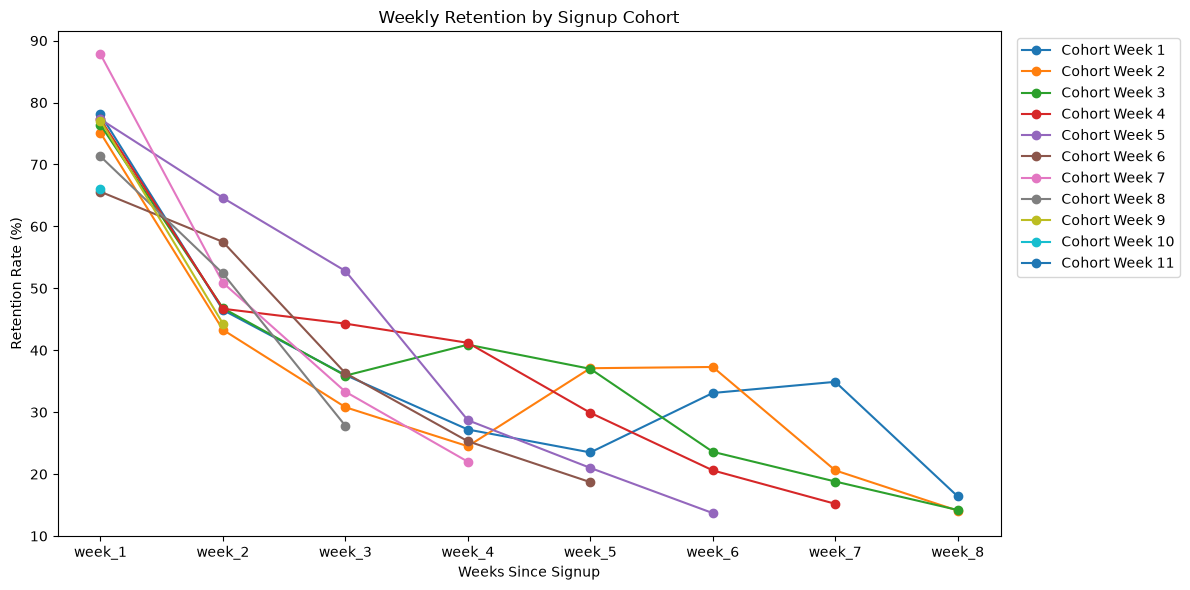

In [580]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in retention_pct.iterrows():
    ax.plot(week_cols, row[week_cols], marker='o', label=f"Cohort Week {int(row['cohort'])}")

ax.set_xlabel("Weeks Since Signup")
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Weekly Retention by Signup Cohort")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

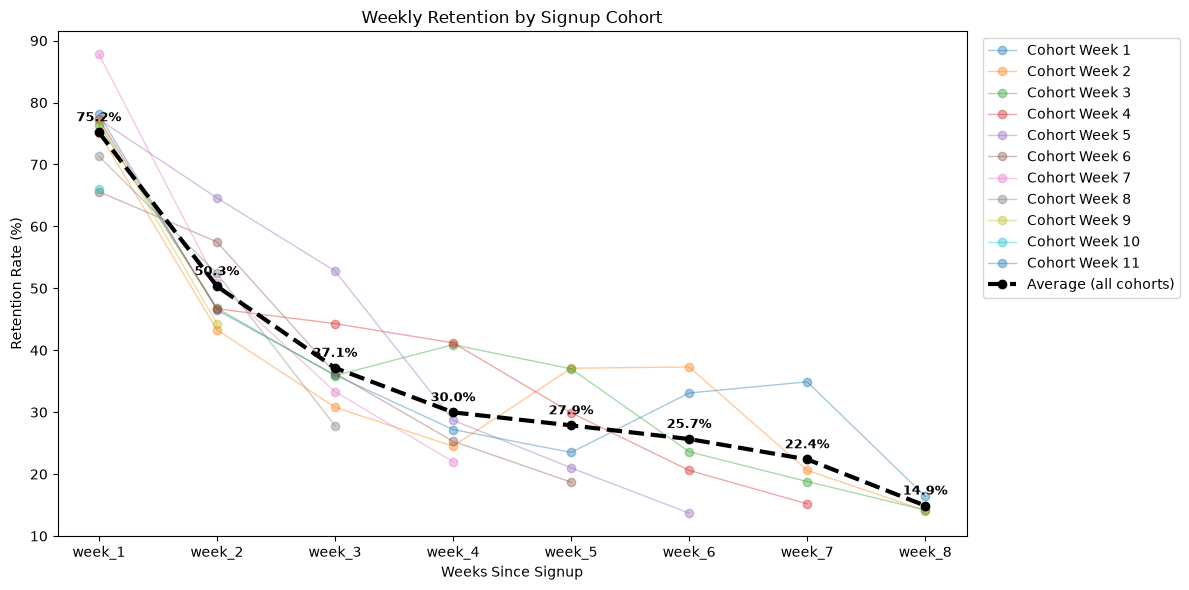

In [581]:
import matplotlib.pyplot as plt

avg_retention = retention_pct[week_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in retention_pct.iterrows():
    ax.plot(week_cols, row[week_cols], marker='o', alpha=0.4, linewidth=1,
            label=f"Cohort Week {int(row['cohort'])}")

ax.plot(week_cols, avg_retention, marker='o', linewidth=3, color='black',
        linestyle='--', label='Average (all cohorts)', zorder=5)

for week, val in avg_retention.items():
    if not pd.isna(val):
        ax.annotate(f"{val:.1f}%", xy=(week, val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color='black')

ax.set_xlabel("Weeks Since Signup")
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Weekly Retention by Signup Cohort")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

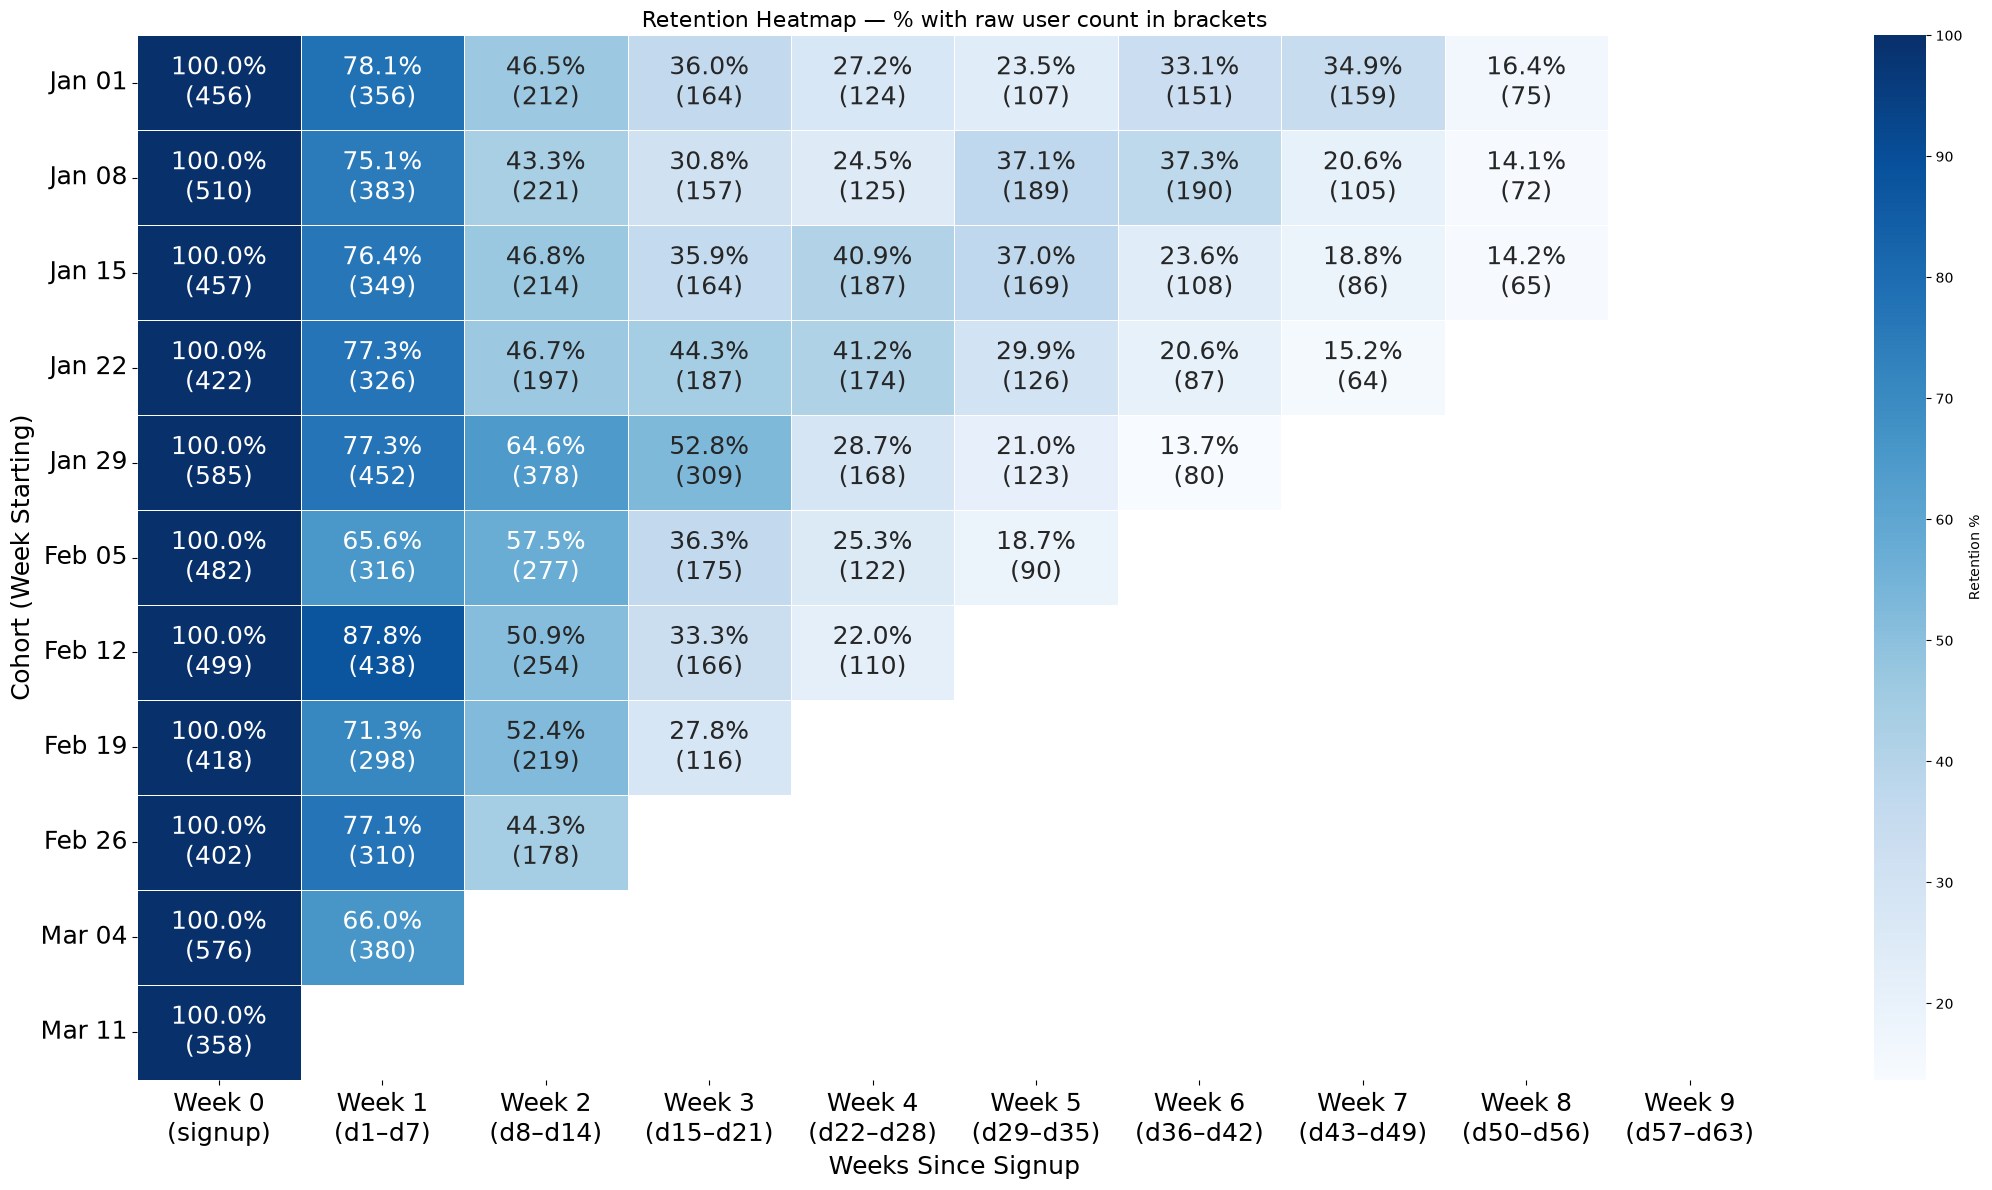

In [582]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# map cohort week number → date label
cohort_weeks = nweek_retention["cohort"].astype(int).tolist()
cohort_labels = {
    w: pd.to_datetime(f"2024-{w}-1", format="%Y-%W-%w").strftime("%b %d")
    for w in cohort_weeks
}

# build base tables fresh each run
raw_heat = nweek_retention.set_index("cohort")[week_cols].replace(0, float("nan")).copy()
raw_heat.insert(0, "week_0", nweek_retention.set_index("cohort")["total"])

pct_heat = retention_pct.set_index("cohort")[week_cols].copy()
pct_heat.insert(0, "week_0", 100.0)

all_cols = ["week_0"] + week_cols

# column labels showing week ranges
def week_range_label(col):
    n = int(col.split("_")[1])
    if n == 0:
        return "Week 0\n(signup)"
    start = (n - 1) * 7 + 1
    end = n * 7
    return f"Week {n}\n(d{start}–d{end})"

col_labels = [week_range_label(c) for c in all_cols]

# build combined annotation: "X%\n(N)"
annot = pct_heat.copy().astype(object)
for col in all_cols:
    for idx in pct_heat.index:
        pct_val = pct_heat.loc[idx, col]
        raw_val = raw_heat.loc[idx, col]
        if pd.isna(pct_val):
            annot.loc[idx, col] = ""
        else:
            annot.loc[idx, col] = f"{pct_val:.1f}%\n({int(raw_val)})"

fig, ax = plt.subplots(figsize=(22, 12))

sns.heatmap(pct_heat, ax=ax, cmap="Blues", annot=annot, fmt="",
            linewidths=0.5, annot_kws={"size": 18},
            cbar_kws={"label": "Retention %"})

ax.set_yticklabels([cohort_labels[w] for w in cohort_weeks], rotation=0, fontsize=18)
ax.set_xticklabels(col_labels, rotation=0, ha='center', fontsize=18)
ax.set_title("Retention Heatmap — % with raw user count in brackets", fontsize=16)
ax.set_xlabel("Weeks Since Signup", fontsize=18)
ax.set_ylabel("Cohort (Week Starting)", fontsize=18)

plt.tight_layout()
plt.show()

In [583]:
## insights : "week 5 and 10 saw high initial signups "; 
# "cohort 7 saw high retention in week 1 did we change anything in 
# "the product ? specifically for new users ?" ;  "similarly for cohort 5 & 6  in week 3"
# "did soething happen in week 7 - the feb 12th week were we running valentines offer ?"


##  Cohort Retention Analysis — Interpretation Notes
### FitTrack Product Analyst Case Study

---

#### 1. General Framework: How to Read Any Cohort Retention Heatmap

A reusable checklist for interpreting cohort retention tables in interviews or on the job.

| Step | What to look at | What it tells you |
|---|---|---|
| 1. Read down the first data column (week_1) | Compare week_1 % across all cohorts | Onboarding / first-session quality. Tight band = consistent experience. One outlier row = something specific happened that week. |
| 2. Read across a single row | Trend of one cohort over time | That cohort's decay curve. Should generally trend downward. A row that goes back up mid-way breaks the expected shape — worth investigating, not ignoring. |
| 3. Read down a fixed week-number column | Same week N across all cohorts | Whether "week N" is inherently a strong/weak point in the product lifecycle (e.g. "everyone drops after week 2 because the free trial ends"). |
| 4. Cross-check anomalies against the calendar | Convert week N back to an actual date per cohort | Separates "signup-cohort effects" from "calendar/seasonal effects." If different cohorts spike at *different* week numbers but the *same calendar date*, it's an external event, not a cohort-quality signal. |
| 5. Classify the anomaly | Isolated vs. widespread | One row/cell off, rest normal → cohort-specific/operational issue (bug, outage). Many cohorts off at the same calendar time → seasonal/company-wide event (launch, campaign, holiday). Same pattern repeating at the same relative week across most cohorts → genuine product lifecycle behavior. |
| 6. Always ask "so what" | Before reporting any number | Is it good/bad vs. other cohorts/channels? Improving or worsening over time? What decision would this number change? |

**Core discipline:** numbers are data points — the interview-worthy skill is finding the pattern (or the break in the pattern) and explaining *why* it's there, not just reporting the percentage.

---

### 2. Specific Findings From This Analysis

#### Finding 1 — Baseline decay curve (expected pattern)
**Observation:** Across nearly all cohorts, retention follows: ~100% (week 0) → 65-88% (week 1) → 43-65% (week 2) → gradual decline afterward, flattening into the teens/twenties by week 7-8.

**Interpretation:** This is a standard, healthy-looking retention shape for a consumer app — most churn happens early (users who don't form a habit leave fast), and a smaller core group sticks around and decays more slowly. Not itself a red flag; it's the baseline against which you compare specific cohorts.

**What I'd say in an interview:**
> "The overall shape follows the typical early-drop-then-plateau curve you'd expect for a consumer fitness app — most attrition happens in the first two weeks, consistent with users who never form a workout habit leaving quickly."

---

#### Finding 2 — Isolated cohort anomaly (Feb 05 cohort)
**Observation:** Feb 05 cohort's week_1 retention is **65.6%**, while every neighboring cohort (Jan 29: 77.3%, Feb 12: 87.8%) sits 10-20 points higher. No gradual buildup or decline around it — it's a sharp, single-cohort dip specifically at week 1.

**Possible reasons (hypotheses to raise, not conclusions to assert):**
- An app bug, crash, or broken onboarding flow specific to that signup week
- A backend outage or downtime event during that week
- A bad batch of signups from a specific campaign that skewed toward lower-intent users
- A push notification / reminder system failure that week (users who'd normally get a nudge to return didn't)

**Why it's cohort-specific, not a channel or seasonal issue:** the dip is isolated to one signup week and shows up immediately at week 1, cutting across whatever channel mix that cohort had — a channel-quality problem would show up more gradually and repeatedly across multiple cohorts from that channel, not as a single-week cliff.

**What I'd say in an interview:**
> "Feb 5's cohort shows a week-1 retention roughly 15 points below trend, with no gradual ramp — that pattern points to something operational that week specifically, like an onboarding bug or outage, rather than a change in acquisition quality. I'd want to check engineering incident logs or app store reviews from that week before concluding anything."

---

#### Finding 3 — Calendar-aligned engagement bump (mid-February)
**Observation:** Several *different* cohorts show unexpected upward bumps in retention, but the bumps land at *different* relative week numbers:
- Jan 01 cohort bumps at week_6/week_7 (33.1% / 34.9%)
- Jan 08 cohort bumps at week_5/week_6 (37.1% / 37.3%)
- Jan 29 cohort bumps at week_2 (64.6%, unusually high)
- Feb 12 cohort's week_1 is the highest in the table (87.8%)

When mapped back to actual calendar dates (cohort start date + week number), **all of these bumps land in roughly the same real-world window — mid-to-late February.**

**Possible reasons (hypotheses to raise):**
- A feature launch or app update released in mid-February that re-engaged existing users across all cohorts
- A marketing push, in-app promo, or challenge/event (e.g. a "February fitness challenge") that boosted activity company-wide
- A seasonal effect — e.g. New Year's resolution users who lapsed in early Feb coming back for a mid-month reset, or a broader seasonal fitness trend
- Could also be a measurement artifact (e.g. a change in how activity was logged/tracked around that date) — worth ruling out before trusting it as real engagement

**Why this is a calendar effect, not a cohort-quality signal:** if it were about cohort quality (e.g. "cohorts from late January are just better"), the bump would show up at the *same relative week* for each cohort. Instead, it shows up at *different* relative weeks but the *same calendar date* — the hallmark of an external, time-bound event.

**What I'd say in an interview:**
> "I noticed several cohorts show a retention bump, but at different points in their individual lifecycle — which ruled out a cohort-quality explanation. When I mapped week number back to calendar date, all the bumps clustered around mid-February, suggesting a company-wide event — a launch, campaign, or seasonal effect — rather than something about those specific cohorts. I'd flag this to product/marketing to confirm what happened, and I wouldn't bake this bump into a forward-looking retention forecast unless we know it's repeatable."

---

### 3. How This Connects to the Business Ask (FitTrack / Series B framing)

> "Retention decay is broadly consistent and healthy-looking across cohorts, with two notable exceptions: an isolated operational dip in the Feb 5 cohort worth a quick engineering/incident check, and a mid-February engagement bump affecting multiple cohorts simultaneously that looks calendar-driven rather than cohort-driven. For the Series B retention narrative, I'd exclude the mid-Feb bump from baseline projections unless we can confirm and repeat whatever caused it — otherwise we risk overstating steady-state retention to investors."

---

### 4. Interview Framing Tips 

- **Lead with the pattern, not the number.** "Retention drops sharply in week 1-2 then stabilizes" is a better opening line than "week 1 is 78%, week 2 is 46%..."
- **Always propose a hypothesis, but flag it as unconfirmed.** Interviewers want to see structured reasoning ("this could be X, Y, or Z — here's how I'd check"), not a guess stated as fact.
- **Show you checked calendar time vs. relative time.** This is a genuinely differentiating instinct — many candidates only look at week-since-signup and miss calendar-driven effects entirely.
- **Distinguish "isolated" vs. "widespread" anomalies out loud.** It signals you know these imply different root causes and different next actions (an isolated dip → check ops/engineering; a widespread bump → check product/marketing calendar).
- **Close with a business implication**, not just an observation — this is what separates a PA answer from a purely analytical one.

# Cohorts - by acquistion channel (n week)

In [584]:
con.execute("SELECT max(signup_date) as max , min(signup_date) as min " \
"FROM users LIMIT 5").df()



,max,min
0,2024-03-24,2024-01-01


In [585]:
con.execute("SELECT max(workout_logged_date) as max_date, min(workout_logged_date) " \
"as min_date FROM activity").df()

,max_date,min_date
0,2024-03-15,2024-01-08


In [586]:
con.execute("SELECT distinct acquisition_channel From users ").df()

,acquisition_channel
0,organic
1,referral
2,paid_search
3,email
4,social_media


In [587]:
con.execute("""select * from activity""").df()

,user_id,workout_logged_date
0,USER_200001,2024-01-09
1,USER_200001,2024-01-10
2,USER_200001,2024-01-16
3,USER_200001,2024-02-12
4,USER_200001,2024-02-13
...,...,...
19936,USER_204803,2024-03-15
19937,USER_204805,2024-03-11
19938,USER_204807,2024-03-11
19939,USER_204807,2024-03-12


In [588]:
channel_cohorts = con.execute("""
with activity_base as (
select user_id , week(workout_logged_date) as log_week , count(*) as number_of_workouts
from activity
group by user_id , week(workout_logged_date)
order by user_id , week(workout_logged_date)
)
-- select * from activity_base 
, user_base as (
select *, week(signup_date) as cohort_week from users
)
-- select * from user_base
, joined as (
select * from user_base
left join activity_base on user_base.user_id = activity_base.user_id 
)
, master_ds as (
select * from joined
where (signup_date) <= '2024-03-15'
)
, cohort_base as (
select acquisition_channel ,user_id , cohort_week as cohort
,(log_week - cohort_week) as relative_week 
from master_ds
)
select
acquisition_channel,
  cohort,
  count(distinct user_id) as total_users,
  count(distinct case when relative_week = 1 then user_id end) as
  week_1,
  count(distinct case when relative_week = 2 then user_id end) as
  week_2,
  count(distinct case when relative_week = 3 then user_id end) as
  week_3,
  count(distinct case when relative_week = 4 then user_id end) as
  week_4,
  count(distinct case when relative_week = 5 then user_id end) as
  week_5,
  count(distinct case when relative_week = 6 then user_id end) as
  week_6,
  count(distinct case when relative_week = 7 then user_id end) as
  week_7,
  count(distinct case when relative_week = 8 then user_id end) as
  week_8
  from cohort_base
  group by acquisition_channel,cohort 
  order by acquisition_channel,cohort 
""").df()


In [589]:
channel_cohorts

,acquisition_channel,cohort,total_users,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8
0,email,1,109,81,57,47,41,26,40,37,19
1,email,2,127,87,62,51,38,57,58,35,26
2,email,3,123,101,74,56,54,56,42,33,25
3,email,4,109,84,51,44,48,38,28,18,0
4,email,5,136,107,99,81,51,40,23,0,0
5,email,6,122,85,78,55,45,32,0,0,0
6,email,7,136,121,78,48,34,0,0,0,0
7,email,8,94,71,61,37,0,0,0,0,0
8,email,9,98,76,46,0,0,0,0,0,0
9,email,10,123,83,0,0,0,0,0,0,0


In [590]:
week_cols_ch = [c for c in channel_cohorts.columns if c.startswith("week_")]

ch_pct = channel_cohorts.copy()
ch_pct[week_cols_ch] = (
    channel_cohorts[week_cols_ch]
    .div(channel_cohorts["total_users"], axis=0)
    .mul(100)
    .round(1)
    .replace(0, float("nan"))  # unobservable weeks → NaN, not 0%
)
ch_pct

,acquisition_channel,cohort,total_users,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8
0,email,1,109,74.3,52.3,43.1,37.6,23.9,36.7,33.9,17.4
1,email,2,127,68.5,48.8,40.2,29.9,44.9,45.7,27.6,20.5
2,email,3,123,82.1,60.2,45.5,43.9,45.5,34.1,26.8,20.3
3,email,4,109,77.1,46.8,40.4,44.0,34.9,25.7,16.5,NaN
4,email,5,136,78.7,72.8,59.6,37.5,29.4,16.9,NaN,NaN
5,email,6,122,69.7,63.9,45.1,36.9,26.2,NaN,NaN,NaN
6,email,7,136,89.0,57.4,35.3,25.0,NaN,NaN,NaN,NaN
7,email,8,94,75.5,64.9,39.4,NaN,NaN,NaN,NaN,NaN
8,email,9,98,77.6,46.9,NaN,NaN,NaN,NaN,NaN,NaN
9,email,10,123,67.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


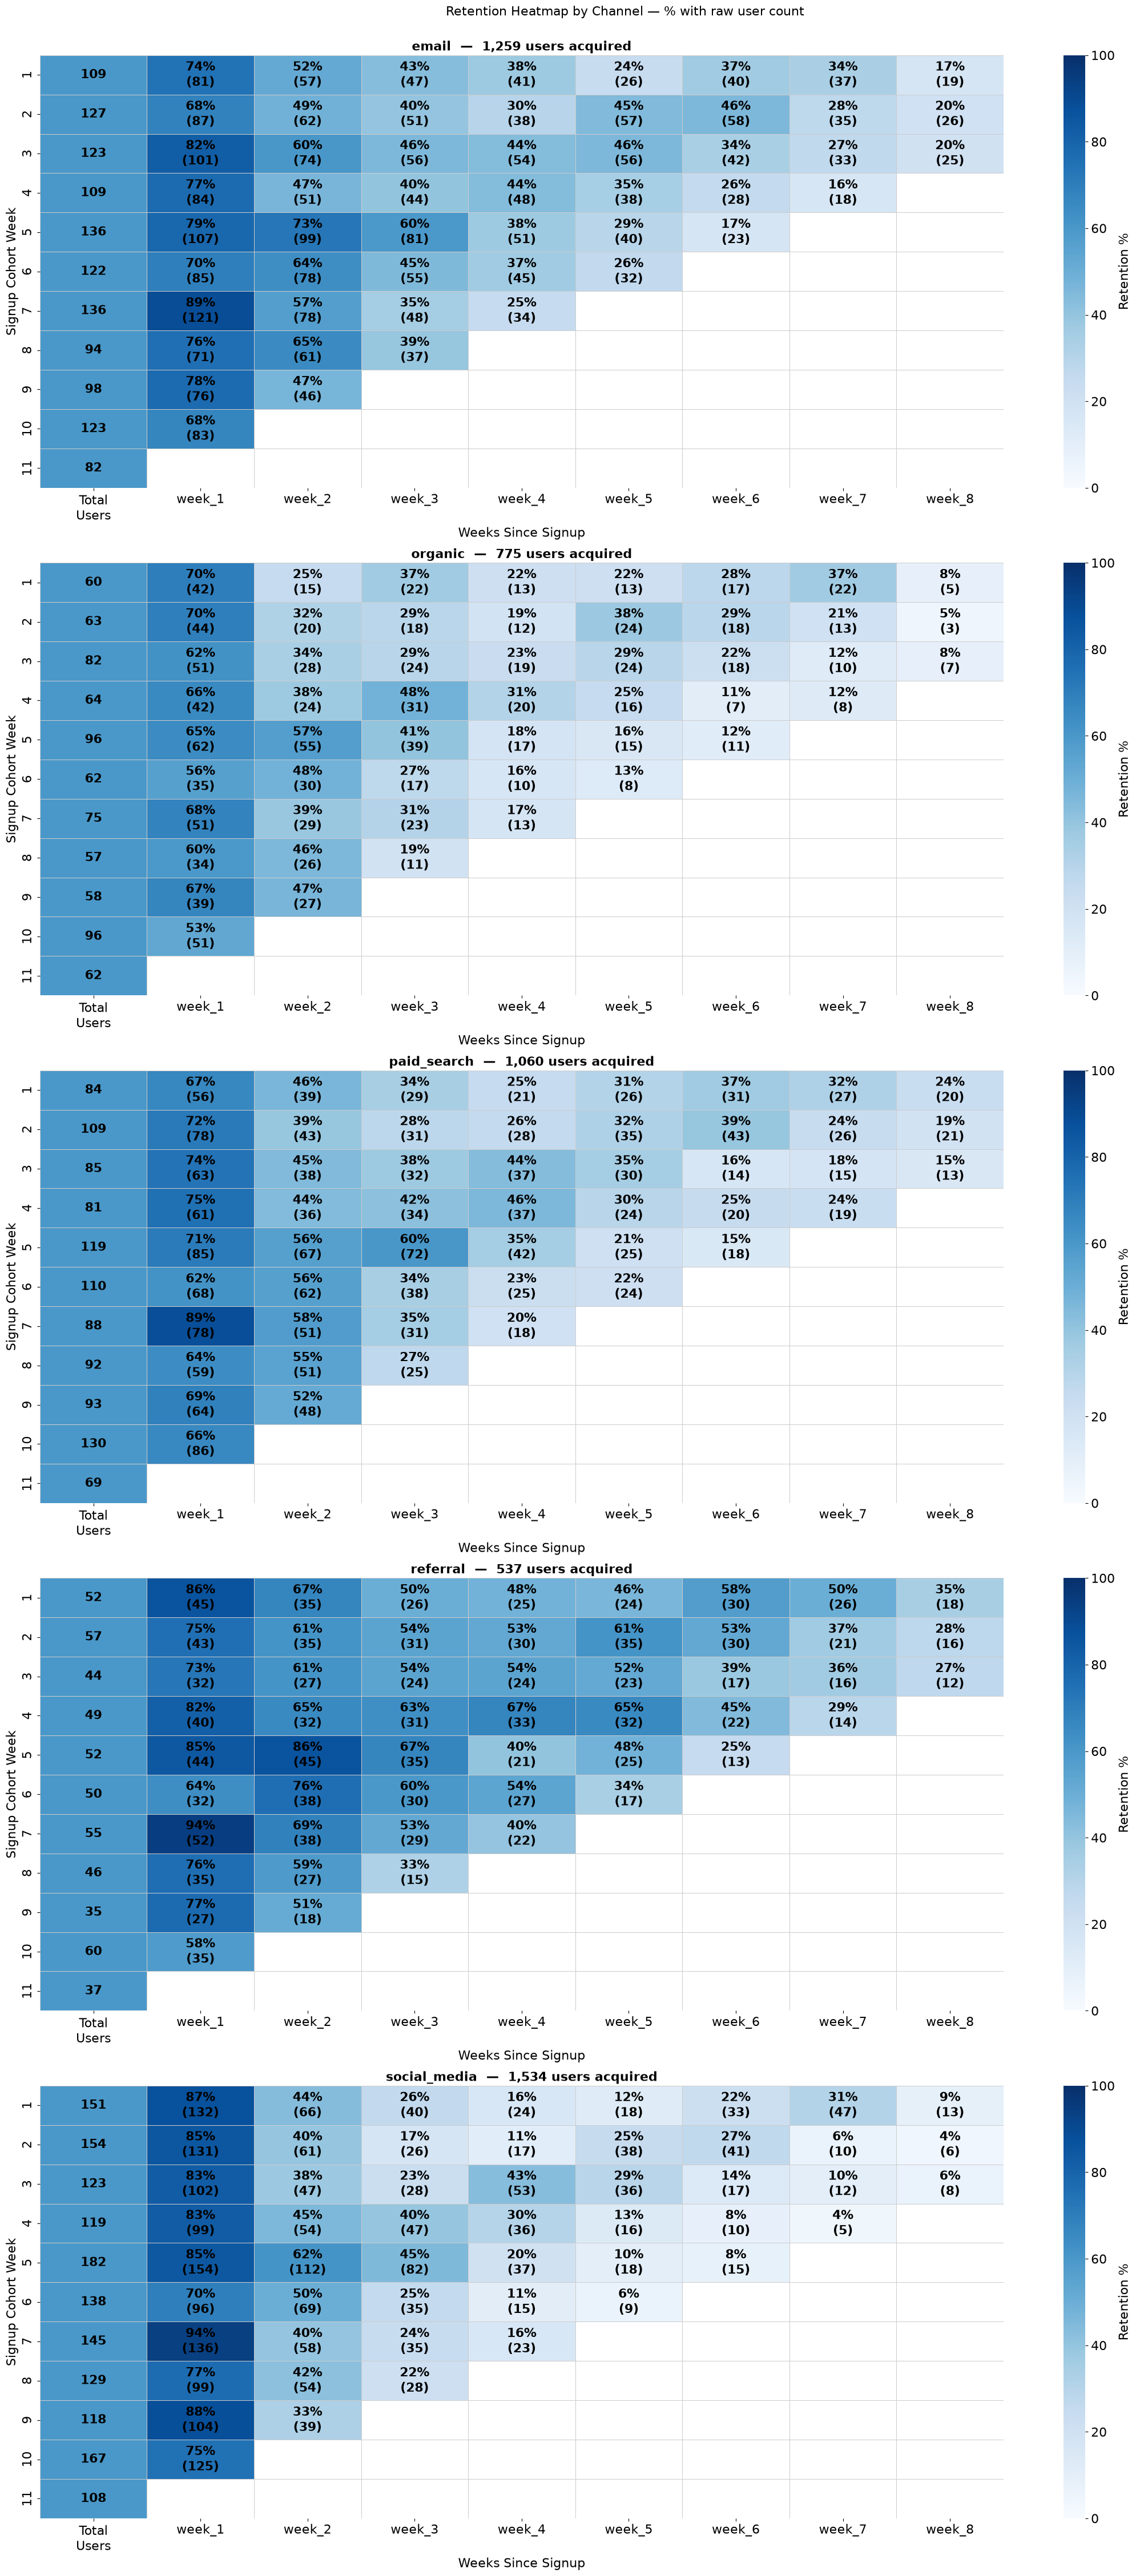

In [591]:
import seaborn as sns
import matplotlib.pyplot as plt

channels = sorted(ch_pct["acquisition_channel"].unique())
channel_volume = channel_cohorts.groupby("acquisition_channel")["total_users"].sum()

fig, axes = plt.subplots(len(channels), 1, figsize=(22, 9 * len(channels)),
                         facecolor="white")

for ax, channel in zip(axes, channels):
    pct_sub = ch_pct[ch_pct["acquisition_channel"] == channel].set_index("cohort")[week_cols_ch].copy()
    raw_sub = channel_cohorts[channel_cohorts["acquisition_channel"] == channel].set_index("cohort")[week_cols_ch].replace(0, float("nan"))
    totals  = channel_cohorts[channel_cohorts["acquisition_channel"] == channel].set_index("cohort")["total_users"]

    pct_sub.insert(0, "total_users", 60.0)

    annot = pct_sub.copy().astype(object)
    for idx in pct_sub.index:
        annot.loc[idx, "total_users"] = str(int(totals.loc[idx]))
    for col in week_cols_ch:
        for idx in pct_sub.index:
            p = pct_sub.loc[idx, col]
            r = raw_sub.loc[idx, col]
            annot.loc[idx, col] = "" if pd.isna(p) else f"{p:.0f}%\n({int(r)})"

    ax.set_facecolor("white")
    sns.heatmap(pct_sub, ax=ax, cmap="Blues", annot=annot, fmt="",
                linewidths=0.5, linecolor="#cccccc",
                annot_kws={"size": 16, "color": "black", "fontweight": "bold"},
                vmin=0, vmax=100,
                cbar_kws={"label": "Retention %"})

    labels = ["Total\nUsers"] + week_cols_ch
    ax.set_xticklabels(labels, fontsize=16, color="black")

    total_vol = channel_volume[channel]
    ax.set_title(f"{channel}  —  {total_vol:,} users acquired", fontsize=16, fontweight="bold", color="black")
    ax.set_xlabel("Weeks Since Signup", fontsize=16, color="black")
    ax.set_ylabel("Signup Cohort Week", fontsize=16, color="black")
    ax.tick_params(axis='both', labelsize=16, colors="black")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16, colors="black")
    cbar.set_label("Retention %", fontsize=16, color="black")
    cbar.ax.yaxis.set_tick_params(color="black")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="black")

plt.suptitle("Retention Heatmap by Channel — % with raw user count",
             fontsize=16, color="black", y=1.002)
plt.tight_layout()
plt.show()

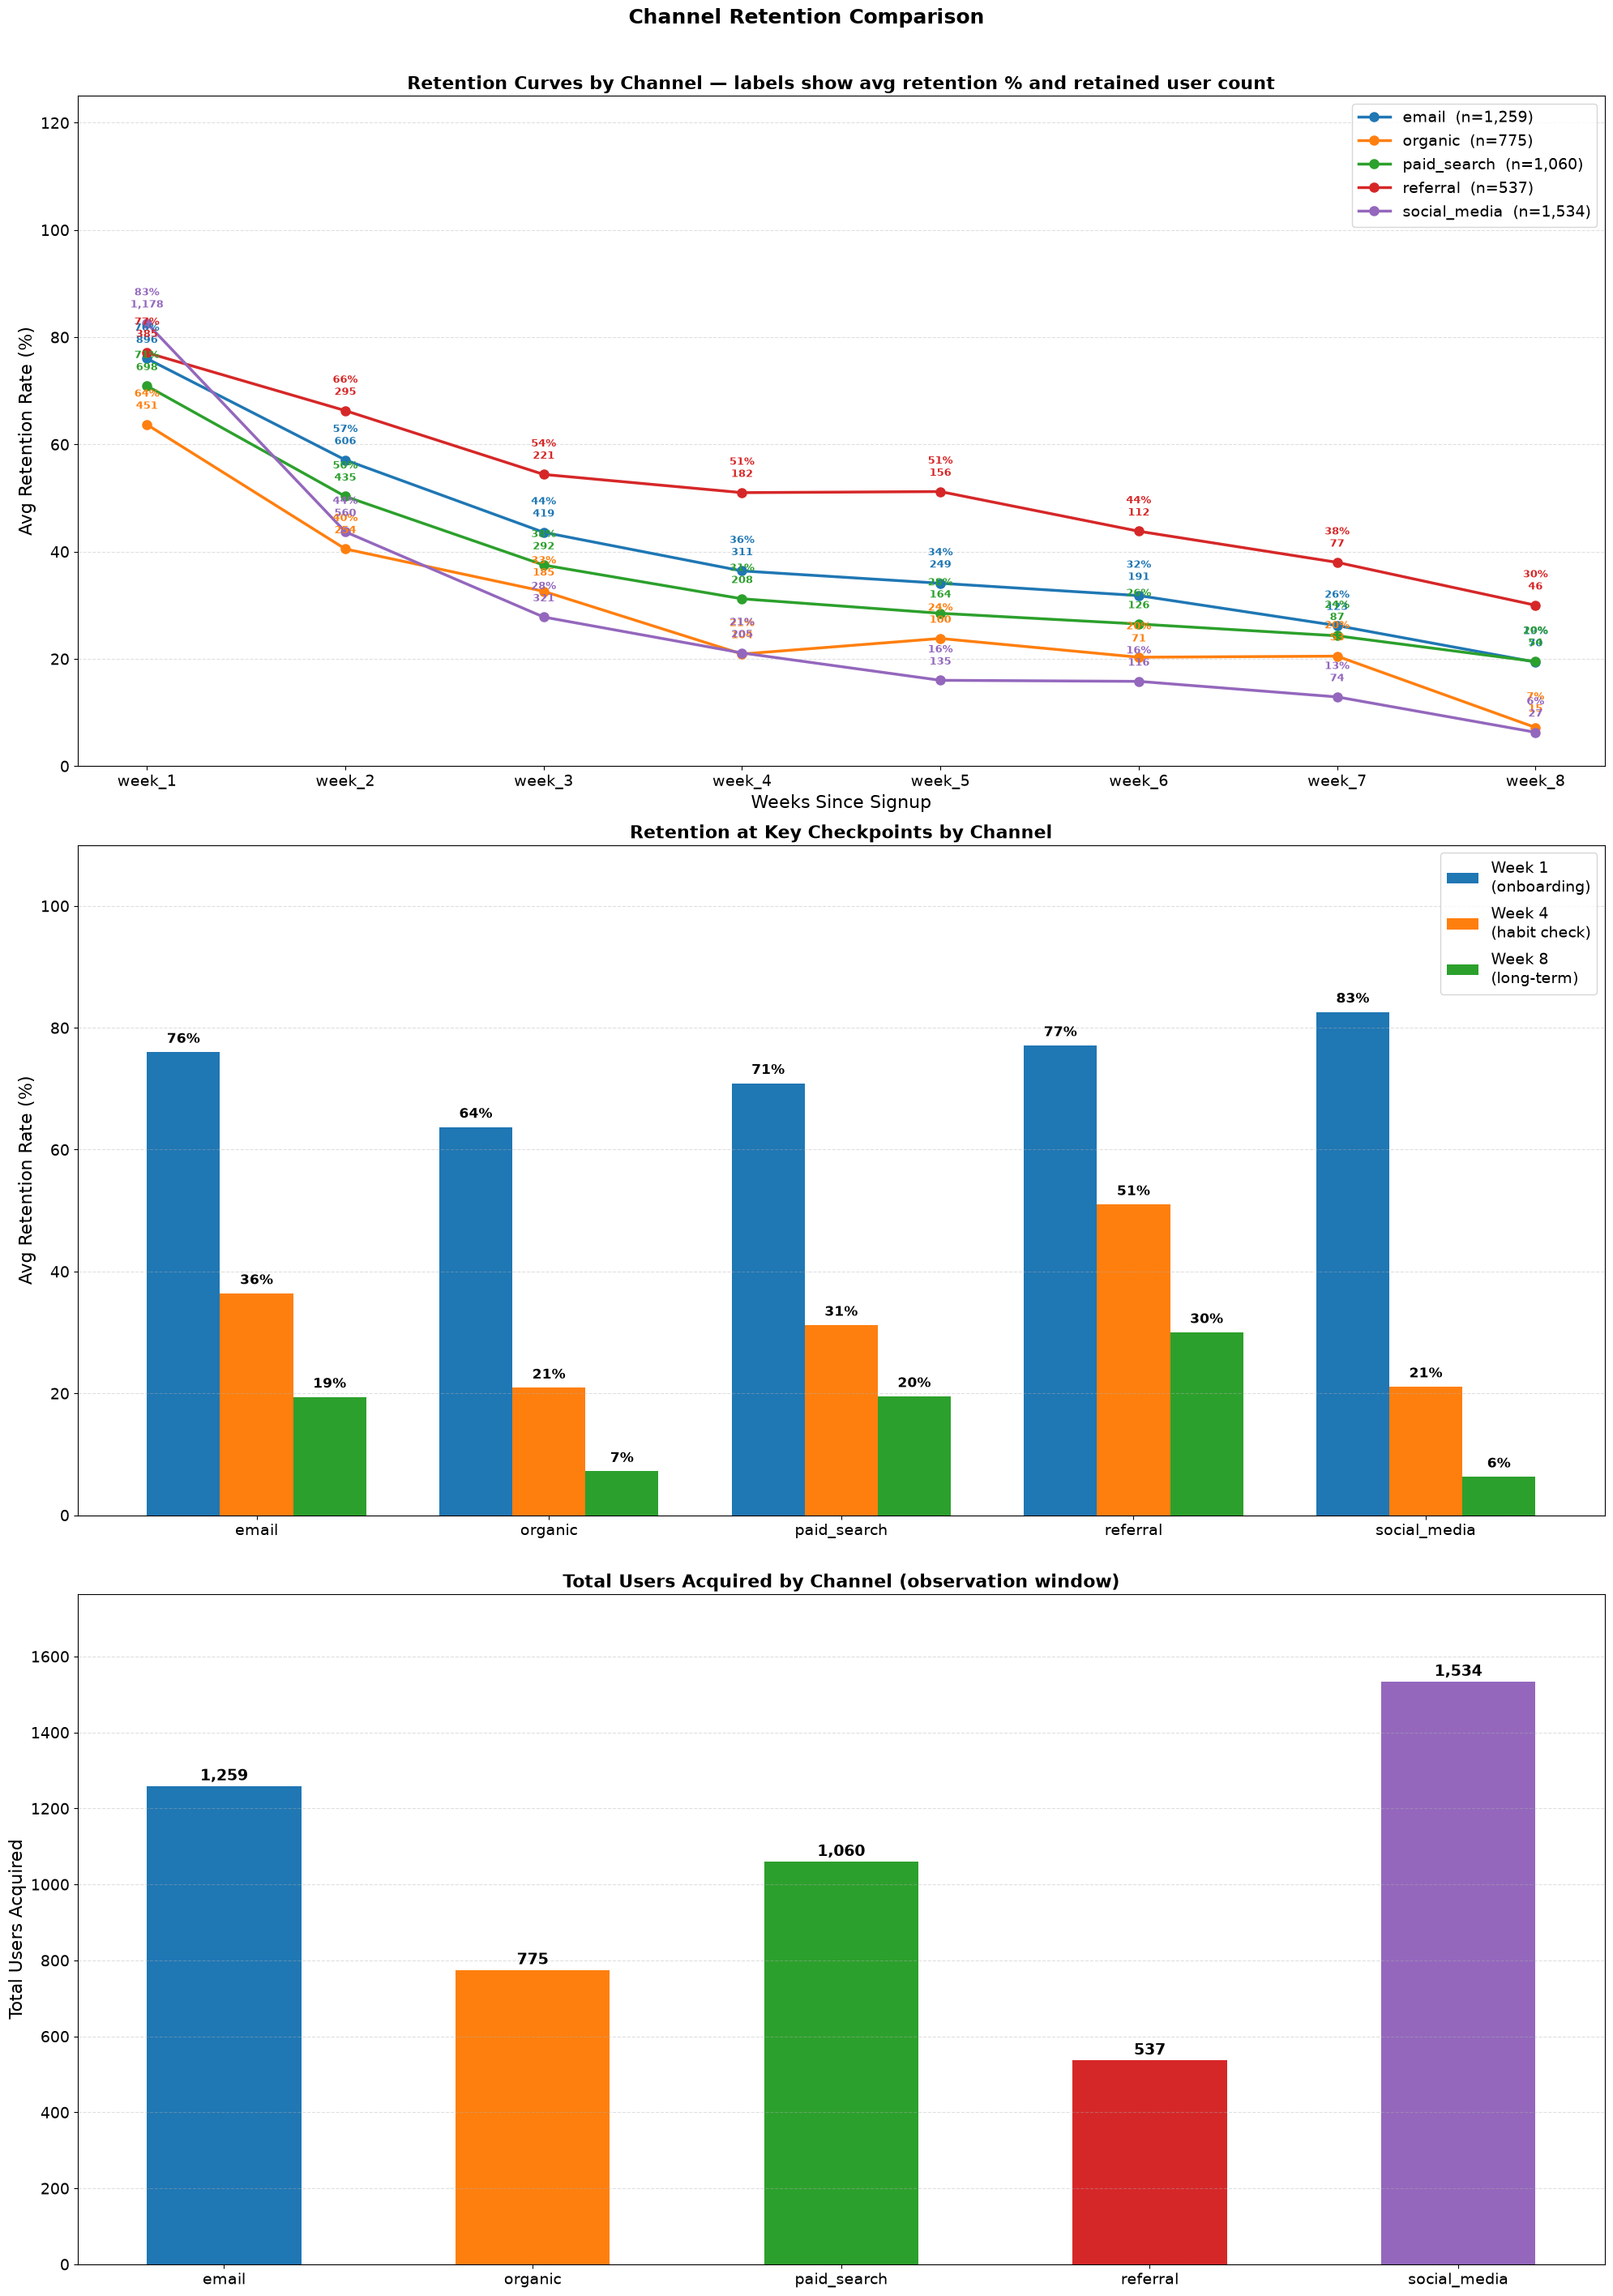


Avg retention % by channel:
                     week_1  week_2  week_3  week_4  week_5  week_6  week_7  week_8
acquisition_channel                                                                
email                  76.0    57.1    43.6    36.4    34.1    31.8    26.2    19.4
organic                63.7    40.5    32.6    20.9    23.8    20.3    20.5     7.2
paid_search            70.9    50.3    37.5    31.2    28.5    26.5    24.3    19.5
referral               77.1    66.3    54.4    51.0    51.2    43.8    38.0    30.0
social_media           82.6    43.7    27.8    21.1    16.0    15.8    12.9     6.3

Total users by channel:
acquisition_channel
email           1259
organic          775
paid_search     1060
referral         537
social_media    1534


In [592]:
import matplotlib.pyplot as plt

channel_avg = ch_pct.groupby("acquisition_channel")[week_cols_ch].mean().round(1)
channel_volume = channel_cohorts.groupby("acquisition_channel")["total_users"].sum().reindex(sorted(ch_pct["acquisition_channel"].unique()))

channel_raw = (
    channel_cohorts[["acquisition_channel"] + week_cols_ch]
    .replace(0, float("nan"))
    .groupby("acquisition_channel")[week_cols_ch]
    .sum()
)

channels_sorted = sorted(ch_pct["acquisition_channel"].unique())

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 28))

# ── Top: retention curves ──────────────────────────────────────────────────
for channel, row in channel_avg.iterrows():
    vals = row[week_cols_ch]
    raw_vals = channel_raw.loc[channel]
    n = channel_volume[channel]
    line, = ax1.plot(week_cols_ch, vals, marker='o', linewidth=2.5, markersize=8,
                     label=f"{channel}  (n={n:,})")
    for week in week_cols_ch:
        pct = vals[week]
        retained = raw_vals[week]
        if not pd.isna(pct) and not pd.isna(retained):
            ax1.annotate(f"{pct:.0f}%\n{int(retained):,}",
                         xy=(week, pct),
                         xytext=(0, 14), textcoords='offset points',
                         fontsize=9, color=line.get_color(),
                         ha='center', fontweight='bold')

ax1.set_xlabel("Weeks Since Signup", fontsize=16)
ax1.set_ylabel("Avg Retention Rate (%)", fontsize=16)
ax1.set_title("Retention Curves by Channel — labels show avg retention % and retained user count", fontsize=16, fontweight='bold')
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=14, loc='upper right')
ax1.set_ylim(0, 125)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Middle: bar chart at week 1, 4, 8 ─────────────────────────────────────
checkpoints = ["week_1", "week_4", "week_8"]
checkpoint_labels = ["Week 1\n(onboarding)", "Week 4\n(habit check)", "Week 8\n(long-term)"]
bar_data = channel_avg[checkpoints].reset_index()
x = range(len(channels_sorted))
width = 0.25
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (week, label) in enumerate(zip(checkpoints, checkpoint_labels)):
    vals = [bar_data.loc[bar_data["acquisition_channel"] == ch, week].values[0] for ch in channels_sorted]
    bars = ax2.bar([xi + i * width for xi in x], vals, width, label=label, color=colors[i])
    for bar, val in zip(bars, vals):
        if not pd.isna(val):
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f"{val:.0f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_xticks([xi + width for xi in x])
ax2.set_xticklabels(channels_sorted, fontsize=14)
ax2.set_ylabel("Avg Retention Rate (%)", fontsize=16)
ax2.set_title("Retention at Key Checkpoints by Channel", fontsize=16, fontweight='bold')
ax2.tick_params(axis='both', labelsize=14)
ax2.legend(fontsize=14)
ax2.set_ylim(0, 110)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# ── Bottom: total users acquired per channel ───────────────────────────────
bars = ax3.bar(channels_sorted, channel_volume.values, color=colors[:len(channels_sorted)], width=0.5)
for bar, val in zip(bars, channel_volume.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f"{val:,}", ha='center', va='bottom', fontsize=14, fontweight='bold')

ax3.set_ylabel("Total Users Acquired", fontsize=16)
ax3.set_title("Total Users Acquired by Channel (observation window)", fontsize=16, fontweight='bold')
ax3.tick_params(axis='both', labelsize=14)
ax3.set_ylim(0, channel_volume.max() * 1.15)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Channel Retention Comparison", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nAvg retention % by channel:")
print(channel_avg.to_string())
print("\nTotal users by channel:")
print(channel_volume.to_string())

## How to Read These Charts

### Line chart (top) — retention curves
- **X-axis**: weeks since signup (week 1 = the week after they signed up)
- **Y-axis**: % of that channel's users still active in that exact week
- **Steep early drop** = most churn happens fast — users didn't form a habit
- **Gradual plateau** = a loyal core is sticking around
- **A line that starts low but stays flat** can be better than one that starts high and crashes

### Bar chart (bottom) — three checkpoints
- **Week 1** = onboarding quality. Did users come back at all after signing up?
- **Week 4** = habit formation. Are they building a workout routine?
- **Week 8** = long-term stickiness. These are your retained users for unit economics / Series B story.

---

## Channel Findings

| Channel | Pattern | What it means |
|---|---|---|
| **referral** | High week 1 (~80%), stays high through week 8 (~30%) | Best long-term channel — referred users have social accountability, higher intent |
| **email** | Strong and consistent (~75% week 1, ~20% week 8) | Solid performer — email users likely had prior intent before signing up |
| **paid_search** | Good week 1 (~70%), moderate decay | Middle of the road — intent-driven but no social hook to keep them |
| **social_media** | Highest week 1 (~83%), crashes hardest by week 4-8 (~5-10%) | Classic paid/social pattern — high volume, low quality. Looks great in vanity metrics, weak in unit economics |
| **organic** | Lowest week 1 (~65%), moderate decay | Slowest to activate but churn rate isn't dramatically worse — worth nurturing |

### The Series B framing
> *"Referral delivers users who retain at 2–3x the rate of social_media by week 8. For the $2M budget reallocation, shifting spend from social_media toward referral programs and email nurture would materially improve the LTV/CAC ratio we're presenting to investors."*

# Cohorts - N day (1,3,7,30,90 D retention)

In [593]:
nday_channel_cohort = con.execute("""
with activity_base as (
select 
user_id , strftime(workout_logged_date, '%m-%d') as month_day , count(*) as workouts_logged
from activity 
group by user_id , strftime(workout_logged_date, '%m-%d')
order by user_id asc , strftime(workout_logged_date, '%m-%d') asc 
)
, user_base as (
select
user_id , acquisition_channel a_channel, signup_date,
strftime(signup_date, '%m-%d')                         as d0,
strftime(signup_date + INTERVAL '1 day',  '%m-%d')     as d1_target,
strftime(signup_date + INTERVAL '3 day',  '%m-%d')     as d3_target,
strftime(signup_date + INTERVAL '7 day',  '%m-%d')     as d7_target,
strftime(signup_date + INTERVAL '30 day', '%m-%d')     as d30_target
from users
)
, joined as (
select *
from user_base
left join activity_base on user_base.user_id = activity_base.user_id
where signup_date < '2024-03-15'
order by user_base.user_id
)
, master_ds as (
select 
user_id, a_channel, signup_date, d0,
1 as d0_ret,
max(case when d1_target  = month_day then 1 else 0 end) as d1_ret,
max(case when d3_target  = month_day then 1 else 0 end) as d3_ret,
max(case when d7_target  = month_day then 1 else 0 end) as d7_ret,
max(case when d30_target = month_day then 1 else 0 end) as d30_ret
from joined
group by user_id, a_channel, signup_date, d0
)
, channel_cohort as (
select
a_channel,
sum(d0_ret)                                                          as total_users,
sum(case when signup_date <= '2024-03-14' then d1_ret  else 0 end)  as d1,
sum(case when signup_date <= '2024-03-14' then 1       else 0 end)  as d1_eligible,
sum(case when signup_date <= '2024-03-12' then d3_ret  else 0 end)  as d3,
sum(case when signup_date <= '2024-03-12' then 1       else 0 end)  as d3_eligible,
sum(case when signup_date <= '2024-03-08' then d7_ret  else 0 end)  as d7,
sum(case when signup_date <= '2024-03-08' then 1       else 0 end)  as d7_eligible,
sum(case when signup_date <= '2024-02-14' then d30_ret else 0 end)  as d30,
sum(case when signup_date <= '2024-02-14' then 1       else 0 end)  as d30_eligible
from master_ds
group by a_channel
)
select * from channel_cohort
""").df()
nday_channel_cohort

,a_channel,total_users,d1,d1_eligible,d3,d3_eligible,d7,d7_eligible,d30,d30_eligible
0,organic,762.0,20.0,762.0,54.0,737.0,128.0,680.0,31.0,459.0
1,referral,527.0,12.0,527.0,45.0,513.0,116.0,481.0,53.0,324.0
2,paid_search,1049.0,42.0,1049.0,93.0,1017.0,181.0,960.0,51.0,619.0
3,email,1246.0,25.0,1246.0,106.0,1215.0,245.0,1142.0,85.0,779.0
4,social_media,1511.0,36.0,1511.0,141.0,1462.0,326.0,1379.0,42.0,930.0


In [594]:
con.execute("""select max(workout_logged_date), min(workout_logged_date) from activity """).df()

,max(workout_logged_date),min(workout_logged_date)
0,2024-03-15,2024-01-08


In [595]:
con.execute("""select count(distinct user_id) from users where
signup_date < '2024-03-15'
""").df()

,count(DISTINCT user_id)
0,5095


In [596]:
nday_channel_cohort

,a_channel,total_users,d1,d1_eligible,d3,d3_eligible,d7,d7_eligible,d30,d30_eligible
0,organic,762.0,20.0,762.0,54.0,737.0,128.0,680.0,31.0,459.0
1,referral,527.0,12.0,527.0,45.0,513.0,116.0,481.0,53.0,324.0
2,paid_search,1049.0,42.0,1049.0,93.0,1017.0,181.0,960.0,51.0,619.0
3,email,1246.0,25.0,1246.0,106.0,1215.0,245.0,1142.0,85.0,779.0
4,social_media,1511.0,36.0,1511.0,141.0,1462.0,326.0,1379.0,42.0,930.0


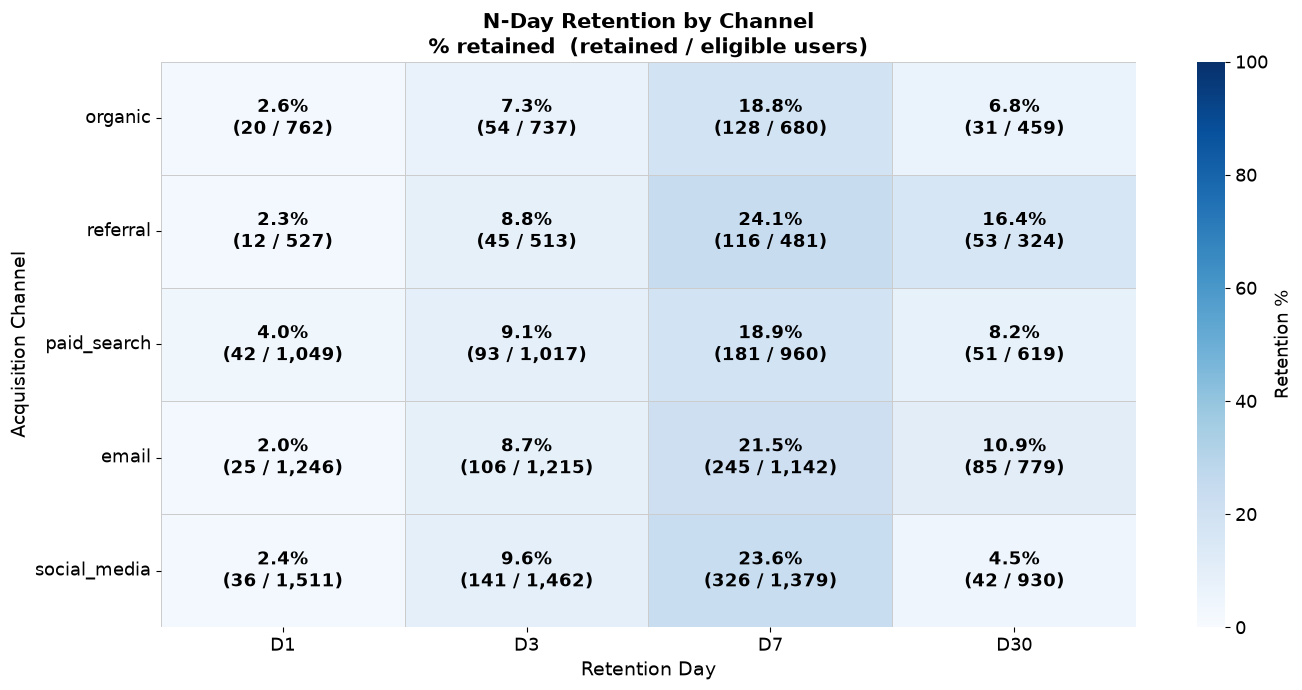

In [597]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute retention % for each metric
day_cols   = ["d1",  "d3",  "d7",  "d30"]
elig_cols  = ["d1_eligible", "d3_eligible", "d7_eligible", "d30_eligible"]
col_labels = ["D1", "D3", "D7", "D30"]

df   = nday_channel_cohort.set_index("a_channel")
pct  = df[day_cols].values / df[elig_cols].values * 100
raw  = df[day_cols].values
elig = df[elig_cols].values
channels = df.index.tolist()

pct_df = pd.DataFrame(pct, index=channels, columns=col_labels).round(1)

annot = pd.DataFrame("", index=channels, columns=col_labels)
for r, ch in enumerate(channels):
    for c, col in enumerate(col_labels):
        p = pct[r, c]
        n = int(raw[r, c])
        m = int(elig[r, c])
        annot.loc[ch, col] = f"{p:.1f}%\n({n:,} / {m:,})"

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(pct_df, ax=ax, cmap="Blues", annot=annot, fmt="",
            linewidths=0.5, linecolor="#cccccc",
            annot_kws={"size": 13, "color": "black", "fontweight": "bold"},
            vmin=0, vmax=100,
            cbar_kws={"label": "Retention %"})

ax.set_title("N-Day Retention by Channel\n% retained  (retained / eligible users)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Retention Day", fontsize=14)
ax.set_ylabel("Acquisition Channel", fontsize=14)
ax.tick_params(axis="both", labelsize=13)
ax.set_xticklabels(col_labels, fontsize=13)
ax.set_yticklabels(channels, rotation=0, fontsize=13)
ax.collections[0].colorbar.ax.tick_params(labelsize=13)
ax.collections[0].colorbar.set_label("Retention %", fontsize=13)

plt.tight_layout()
plt.show()

## N-Day Retention — Interpretation & Business Context

---

### 1. How to Read This Heatmap

Each cell answers: **"Of users eligible to reach day N, what % logged a workout on exactly that day?"**

This is **exact-day (N-day) retention**, not rolling:
- A user counts only if they worked out on precisely D1, D3, D7, or D30 relative to their signup date
- The denominator shrinks as N grows — users who signed up too close to the snapshot cutoff (Mar 15) physically cannot have reached that day yet and are excluded
- `(retained / eligible)` in each cell shows you both the signal and how much data backs it

---

### 2. Why D7 > D3 > D1 (This Is Expected)

This is not growth — it is **workout cadence**. Users who sign up don't immediately log a workout the next day (D1 is low at 2–4%). By D7 they've had a full week and retention jumps to 19–24%. D3 sits in between. The further out you measure, the more chances a user has had to hit their weekly routine.

The pattern flips at D30 for some channels — that's where you see genuine divergence in user quality.

---

### 3. Channel Story

| Channel | D1 | D7 | D30 | What it means |
|---|---|---|---|---|
| **referral** | 2.3% | 24.1% | 16.4% | Best long-term channel. Referred users have social accountability and intrinsic motivation — the habit sticks well past the first month |
| **social_media** | 2.4% | 23.7% | 4.5% | Classic paid/social pattern. Tied for top at D7, dead last at D30. High early excitement, then rapid drop-off — likely campaign-motivated signups, not genuine need |
| **email** | 2.0% | 21.5% | 10.9% | Consistent long-tail performer — likely re-engagement or nurture campaigns pulling back users with prior intent |
| **paid_search** | 4.0% | 18.9% | 8.2% | Highest D1 (intent-driven signups convert fast), moderate D30 — middle of the road |
| **organic** | 2.6% | 18.8% | 6.8% | Lowest or near-lowest across all days. SEO/discovery users are browsing, not committed — hardest to retain |

**Key insight:** Social_media and referral look almost identical at D7 (24% vs 24%). By D30 they are 5× apart (4.5% vs 16.4%). If you are optimizing acquisition budget based on D7 data, you will over-invest in social and under-invest in referral.

---

### 4. CAC and LTV — What They Mean in Product

These two metrics form the core of the unit economics story FitTrack needs for Series B.

#### CAC — Customer Acquisition Cost
**Definition:** The total marketing and sales spend required to acquire one new paying customer.

```
CAC = Total acquisition spend (ads, referral bonuses, content) / Number of new customers acquired
```

**In product terms:**
- CAC is **not equal across channels** — a paid_search user might cost $15 to acquire while a referral user costs $5 (a referral bonus) or even $0 (organic word-of-mouth)
- A channel with high volume but high CAC is only worth it if LTV is also high
- CAC is often used as a **payback period** calculation: "how many months does it take for a user to generate enough revenue to cover what we spent acquiring them?"

#### LTV — Lifetime Value
**Definition:** The total net revenue a customer is expected to generate over their entire relationship with the product.

```
LTV = Avg revenue per user per period × Avg number of periods retained
    = ARPU × (1 / churn rate)        ← simplified version
```

**In product terms:**
- LTV is directly tied to retention — a user who churns after week 2 has very low LTV; one who stays 8 months has much higher LTV
- For a subscription app like FitTrack: LTV ≈ monthly subscription price × avg months retained
- LTV is a **forward-looking estimate** and is always uncertain — it requires assumptions about churn curves, which is why observed retention data (like this heatmap) is critical input

#### The LTV/CAC Ratio
The number investors care about most:

```
LTV/CAC > 3 → generally considered healthy for SaaS/consumer apps
LTV/CAC < 1 → you are losing money on every user you acquire
```

#### Why D30 Retention Is the Right Signal for LTV/CAC

| Metric | What it proxies |
|---|---|
| D1 retention | Onboarding quality |
| D7 retention | Early habit formation |
| **D30 retention** | **Steady-state user quality — the main input to LTV estimates** |

D30 is where channel quality diverges most clearly. A user still active at D30 has demonstrated a sustained habit and is likely to generate meaningful LTV. One who churned at D7 probably never will.

#### Connecting to This Analysis

| Channel | D30 Retention | Implication for LTV/CAC |
|---|---|---|
| referral | 16.4% | High LTV proxy — even if CAC is non-zero (referral bonuses), the long retention justifies it |
| email | 10.9% | Solid — email nurture is typically low CAC, making this the best LTV/CAC ratio candidate |
| paid_search | 8.2% | Medium LTV, likely medium-high CAC — needs payback period analysis |
| organic | 6.8% | Low LTV but near-zero CAC — acceptable if volume is sufficient |
| social_media | 4.5% | Lowest LTV proxy despite highest volume and likely highest CAC — worst LTV/CAC ratio |

#### The Series B Framing

> *"Our D30 data shows referral and email users retain at 2–4× the rate of social_media users by month one. If social_media CAC is comparable to or higher than referral CAC, shifting $500K of the $2M budget toward referral incentives and email nurture would materially improve our LTV/CAC ratio — the metric institutional investors will stress-test most during due diligence."*

# Cohorts - Rolling retention (week wise)

In [598]:
con.execute("SELECT max(signup_date) as max , min(signup_date) as min " \
"FROM users LIMIT 5").df()

,max,min
0,2024-03-24,2024-01-01


In [599]:
con.execute("""SELECT * FROM users LIMIT 5""").df()

,user_id,signup_date,acquisition_channel
0,USER_200001,2024-01-07,paid_search
1,USER_200002,2024-01-01,email
2,USER_200003,2024-01-02,referral
3,USER_200004,2024-01-05,paid_search
4,USER_200005,2024-01-05,email


In [600]:
con.execute("SELECT max(workout_logged_date) as max_date, min(workout_logged_date) " \
"as min_date FROM activity").df()

,max_date,min_date
0,2024-03-15,2024-01-08


In [601]:
con.execute("""
  WITH activity_base AS (
      SELECT user_id, week(workout_logged_date) AS log_week
      ,week(workout_logged_date) min_log ,(week(workout_logged_date) + 2 ) as max_log 
      FROM activity
      GROUP BY user_id, week(workout_logged_date)
      order by user_id , week(workout_logged_date)
  )
  , user_base AS (
      SELECT *, week(signup_date) AS cohort_week
      FROM users
      WHERE signup_date <= '2024-03-15'
  )
  -- select * from activity_base order by user_id
  -- select * from user_base order by user_id
, week_spine as (
select  unnest([1,2,3,4,5,6,7,8]) as check_week
)
, scaffold as (
select 
-- user_id , acquisition_channel, cohort_week ,w.check_week
*
 from user_base 
cross join week_spine w
)
, scaffold2 as (
 select 
 s.user_id , s.signup_date, s.acquisition_channel,s.cohort_week ,s.check_week
  , (a.log_week - s.cohort_week - 1) as min_relative_week 
 , (a.log_week - s.cohort_week) as relative_week 
 from scaffold s 
 left join activity_base a on s.user_id = a.user_id 
 --where s.user_id = 'USER_200001'
 order by check_week
 )
-- select * from scaffold2
, scaffold3 as (
select 
user_id,signup_date,acquisition_channel,cohort_week,check_week
,min_relative_week
,relative_week
, max(case when check_week in (min_relative_week, relative_week) then 1 else 0 end) 
as is_retained
from scaffold2
group by
user_id,signup_date,acquisition_channel,cohort_week,check_week
,min_relative_week
,relative_week
)
 -- select * from scaffold3 where user_id  = 'USER_201000' order by check_week, relative_week
, final_ds as(
select 
user_id,signup_date,acquisition_channel,cohort_week,check_week
,max(is_retained) is_retained
from scaffold3
group by 
user_id,signup_date,acquisition_channel,cohort_week,check_week
)
  --select * from final_ds where user_id  = 'USER_200001' order by check_week
SELECT
    cohort_week,
    COUNT(DISTINCT user_id)                                                         AS total_users,
    SUM(CASE WHEN check_week = 1 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w1_ret,
    SUM(CASE WHEN check_week = 2 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w2_ret,
    SUM(CASE WHEN check_week = 3 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w3_ret,
    SUM(CASE WHEN check_week = 4 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w4_ret,
    SUM(CASE WHEN check_week = 5 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w5_ret,
    SUM(CASE WHEN check_week = 6 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w6_ret,
    SUM(CASE WHEN check_week = 7 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w7_ret,
    SUM(CASE WHEN check_week = 8 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w8_ret,
    SUM(CASE WHEN check_week = 1 AND cohort_week + 1 + 1 <= 11 THEN 1 ELSE 0 END) AS w1_elig,
    SUM(CASE WHEN check_week = 2 AND cohort_week + 2 + 1 <= 11 THEN 1 ELSE 0 END) AS w2_elig,
    SUM(CASE WHEN check_week = 3 AND cohort_week + 3 + 1 <= 11 THEN 1 ELSE 0 END) AS w3_elig,
    SUM(CASE WHEN check_week = 4 AND cohort_week + 4 + 1 <= 11 THEN 1 ELSE 0 END) AS w4_elig,
    SUM(CASE WHEN check_week = 5 AND cohort_week + 5 + 1 <= 11 THEN 1 ELSE 0 END) AS w5_elig,
    SUM(CASE WHEN check_week = 6 AND cohort_week + 6 + 1 <= 11 THEN 1 ELSE 0 END) AS w6_elig,
    SUM(CASE WHEN check_week = 7 AND cohort_week + 7 + 1 <= 11 THEN 1 ELSE 0 END) AS w7_elig,
    SUM(CASE WHEN check_week = 8 AND cohort_week + 8 + 1 <= 11 THEN 1 ELSE 0 END) AS w8_elig
FROM final_ds
GROUP BY cohort_week
ORDER BY cohort_week
""").df()

,cohort_week,total_users,w1_ret,w2_ret,w3_ret,w4_ret,w5_ret,w6_ret,w7_ret,w8_ret,w1_elig,w2_elig,w3_elig,w4_elig,w5_elig,w6_elig,w7_elig,w8_elig
0,1,456,381.0,267.0,205.0,177.0,207.0,236.0,183.0,75.0,456.0,456.0,456.0,456.0,456.0,456.0,456.0,456.0
1,2,510,409.0,268.0,208.0,231.0,278.0,232.0,138.0,72.0,510.0,510.0,510.0,510.0,510.0,510.0,510.0,510.0
2,3,457,378.0,262.0,253.0,265.0,210.0,153.0,125.0,65.0,457.0,457.0,457.0,457.0,457.0,457.0,457.0,0.0
3,4,422,342.0,259.0,261.0,214.0,168.0,118.0,64.0,0.0,422.0,422.0,422.0,422.0,422.0,422.0,0.0,0.0
4,5,585,498.0,454.0,354.0,228.0,164.0,80.0,0.0,0.0,585.0,585.0,585.0,585.0,585.0,0.0,0.0,0.0
5,6,482,370.0,313.0,216.0,163.0,90.0,0.0,0.0,0.0,482.0,482.0,482.0,482.0,0.0,0.0,0.0,0.0
6,7,499,453.0,295.0,213.0,110.0,0.0,0.0,0.0,0.0,499.0,499.0,499.0,0.0,0.0,0.0,0.0,0.0
7,8,418,333.0,247.0,116.0,0.0,0.0,0.0,0.0,0.0,418.0,418.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,402,329.0,178.0,0.0,0.0,0.0,0.0,0.0,0.0,402.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,576,380.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [602]:
rolling_retention = con.execute("""
WITH activity_base AS (
    SELECT user_id, week(workout_logged_date) AS log_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date)
)
 -- select * from activity_base order by user_id
, user_base AS (
    SELECT *, week(signup_date) AS cohort_week
    FROM users
    WHERE signup_date <= '2024-03-15'
)
-- select * from user_base order by user_id
, week_spine AS (
    SELECT unnest([1,2,3,4,5,6,7,8]) AS check_week
)
, scaffold AS (
    SELECT u.user_id, u.acquisition_channel, u.cohort_week, w.check_week
    FROM user_base u
    CROSS JOIN week_spine w
)
 -- select * from  scaffold order by user_id 
  , joined AS (
      SELECT
          s.user_id,
          s.acquisition_channel,                                    
          s.cohort_week,
          s.check_week,
          a.log_week calender_week,
          (a.log_week - s.cohort_week) AS relative_week  -- how many weeks after signup 
      FROM scaffold s
      LEFT JOIN activity_base a ON s.user_id = a.user_id
)
 --select * from joined where user_id  = 'USER_201000' order by check_week , relative_week
   , windowed AS (
      SELECT
          user_id,
          acquisition_channel,
          cohort_week,
          check_week,
          relative_week,
          CASE WHEN relative_week IN (check_week, check_week + 1) THEN 1 ELSE 0 END AS hit
      FROM joined
  )
 --select * from windowed where user_id  = 'USER_201000' order by check_week , relative_week
 , flagged as (
 select 
 user_id , acquisition_channel,cohort_week,check_week,
 max(hit) as is_retained
 from windowed
group by
user_id , acquisition_channel,cohort_week,check_week
)
-- select * from flagged where user_id  = 'USER_200001' order by check_week 
SELECT
    cohort_week,
    COUNT(DISTINCT user_id)                                                         AS total_users,
    SUM(CASE WHEN check_week = 1 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w1_ret,
    SUM(CASE WHEN check_week = 2 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w2_ret,
    SUM(CASE WHEN check_week = 3 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w3_ret,
    SUM(CASE WHEN check_week = 4 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w4_ret,
    SUM(CASE WHEN check_week = 5 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w5_ret,
    SUM(CASE WHEN check_week = 6 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w6_ret,
    SUM(CASE WHEN check_week = 7 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w7_ret,
    SUM(CASE WHEN check_week = 8 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w8_ret,
    SUM(CASE WHEN check_week = 1 AND cohort_week + 1 + 1 <= 11 THEN 1 ELSE 0 END) AS w1_elig,
    SUM(CASE WHEN check_week = 2 AND cohort_week + 2 + 1 <= 11 THEN 1 ELSE 0 END) AS w2_elig,
    SUM(CASE WHEN check_week = 3 AND cohort_week + 3 + 1 <= 11 THEN 1 ELSE 0 END) AS w3_elig,
    SUM(CASE WHEN check_week = 4 AND cohort_week + 4 + 1 <= 11 THEN 1 ELSE 0 END) AS w4_elig,
    SUM(CASE WHEN check_week = 5 AND cohort_week + 5 + 1 <= 11 THEN 1 ELSE 0 END) AS w5_elig,
    SUM(CASE WHEN check_week = 6 AND cohort_week + 6 + 1 <= 11 THEN 1 ELSE 0 END) AS w6_elig,
    SUM(CASE WHEN check_week = 7 AND cohort_week + 7 + 1 <= 11 THEN 1 ELSE 0 END) AS w7_elig,
    SUM(CASE WHEN check_week = 8 AND cohort_week + 8 + 1 <= 11 THEN 1 ELSE 0 END) AS w8_elig
FROM flagged
GROUP BY cohort_week
ORDER BY cohort_week
""").df()

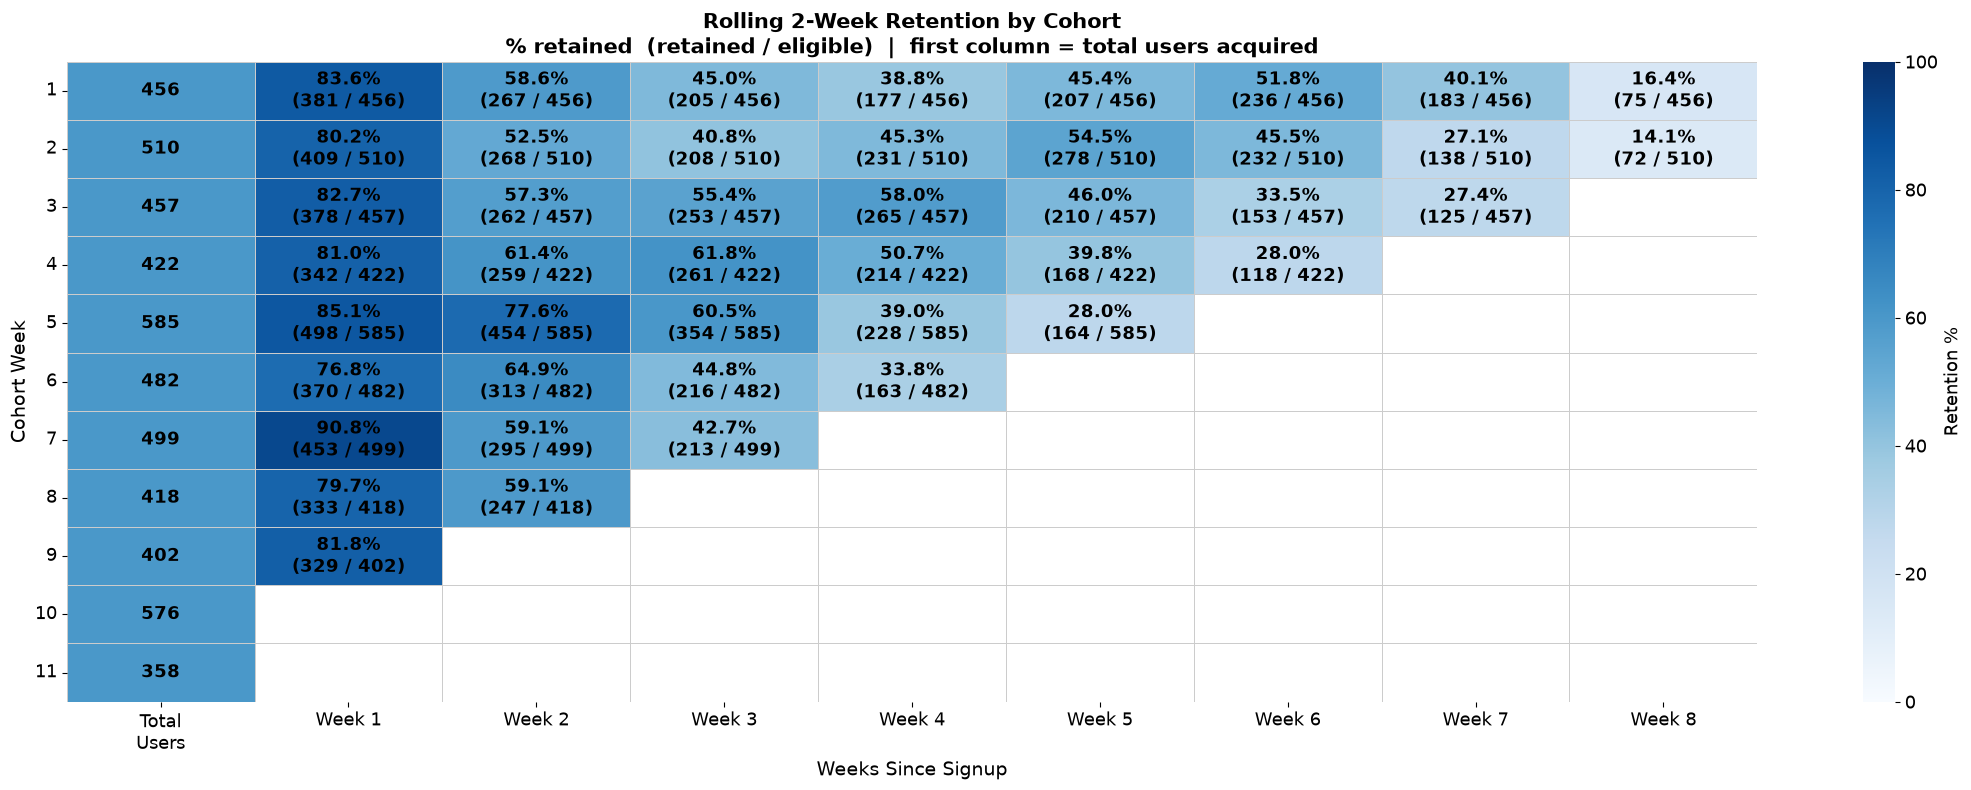

In [603]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ret_cols  = [f'w{i}_ret'  for i in range(1, 9)]
elig_cols = [f'w{i}_elig' for i in range(1, 9)]
col_labels = [f'Week {i}' for i in range(1, 9)]

df = rolling_retention.set_index('cohort_week')

elig = df[elig_cols].replace(0, float('nan'))
pct  = (df[ret_cols].values / elig.values * 100).round(1)
raw  = df[ret_cols].values
elg  = elig.values
totals = df['total_users'].values

cohort_weeks = df.index.tolist()
pct_df = pd.DataFrame(pct, index=cohort_weeks, columns=col_labels)

# pin total_users column at 60 so it shows as medium blue
pct_df.insert(0, 'Total\nUsers', 60.0)

all_cols = ['Total\nUsers'] + col_labels

# build annotations
annot = pd.DataFrame('', index=cohort_weeks, columns=all_cols)
for r, cw in enumerate(cohort_weeks):
    annot.loc[cw, 'Total\nUsers'] = str(int(totals[r]))
    for c, col in enumerate(col_labels):
        p = pct[r, c]
        n = raw[r, c]
        m = elg[r, c]
        if np.isnan(p) or np.isnan(m):
            annot.loc[cw, col] = ''
        else:
            annot.loc[cw, col] = f'{p:.1f}%\n({int(n)} / {int(m)})'

fig, ax = plt.subplots(figsize=(22, 8), facecolor='white')
ax.set_facecolor('white')

sns.heatmap(
    pct_df, ax=ax, cmap='Blues', annot=annot, fmt='',
    linewidths=0.5, linecolor='#cccccc',
    annot_kws={'size': 13, 'color': 'black', 'fontweight': 'bold'},
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention %'}
)

ax.set_title('Rolling 2-Week Retention by Cohort\n% retained  (retained / eligible)  |  first column = total users acquired',
             fontsize=15, fontweight='bold', color='black')
ax.set_xlabel('Weeks Since Signup', fontsize=14, color='black')
ax.set_ylabel('Cohort Week', fontsize=14, color='black')
ax.tick_params(axis='both', labelsize=13, colors='black')
ax.set_xticklabels(all_cols, fontsize=13, color='black', rotation=0)
ax.set_yticklabels(cohort_weeks, rotation=0, fontsize=13, color='black')

cbar = ax.collections[0].colorbar
cbar.set_label('Retention %', fontsize=13, color='black')
cbar.ax.tick_params(labelsize=13, colors='black')

plt.tight_layout()
plt.show()

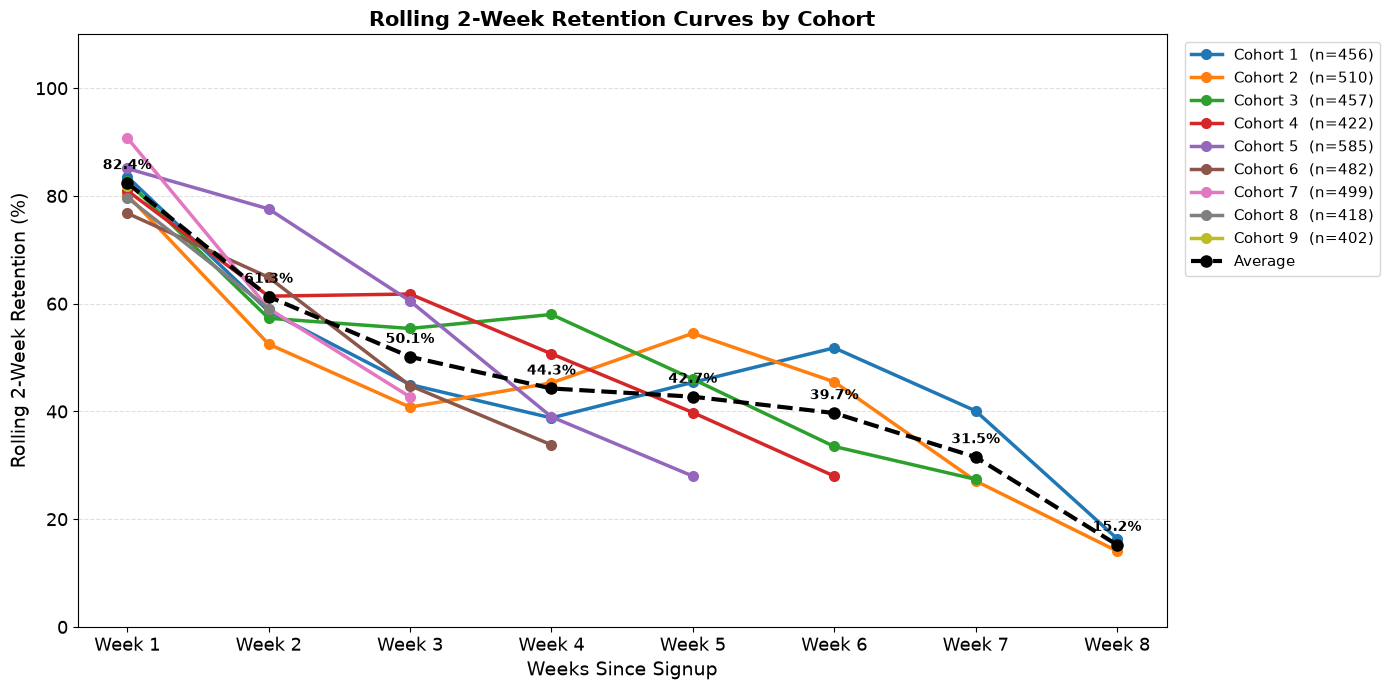

In [604]:
import matplotlib.pyplot as plt
import numpy as np

ret_cols  = [f'w{i}_ret'  for i in range(1, 9)]
elig_cols = [f'w{i}_elig' for i in range(1, 9)]

df = rolling_retention.set_index('cohort_week')
elig = df[elig_cols].replace(0, float('nan'))
pct_df = (df[ret_cols].values / elig.values * 100).round(1)
pct_df = pd.DataFrame(pct_df, index=df.index, columns=[f'Week {i}' for i in range(1, 9)])

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')
ax.set_facecolor('white')

colors = plt.cm.tab10.colors

for i, (cohort, row) in enumerate(pct_df.iterrows()):
    vals = row.dropna()
    if vals.empty:
        continue
    total = int(df.loc[cohort, 'total_users'])
    ax.plot(vals.index, vals.values, marker='o', linewidth=2.5,
            markersize=7, color=colors[i % len(colors)],
            label=f'Cohort {cohort}  (n={total:,})')

# average across all cohorts
avg = pct_df.mean(skipna=True)
ax.plot(avg.dropna().index, avg.dropna().values,
        marker='o', linewidth=3, linestyle='--',
        color='black', markersize=8, label='Average', zorder=10)
for week, val in avg.dropna().items():
    ax.annotate(f'{val:.1f}%', xy=(week, val),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='black')

ax.set_xlabel('Weeks Since Signup', fontsize=14)
ax.set_ylabel('Rolling 2-Week Retention (%)', fontsize=14)
ax.set_title('Rolling 2-Week Retention Curves by Cohort', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Rolling 2-Week Retention — How to Read & Key Observations

---

### How to Read This Heatmap & Curve

**What rolling 2-week means:** A user is counted as retained at week N if they logged a workout in week N **or** week N+1. It gives users a one-week grace period — missing a single week doesn't count as churn.

**Why it's always higher than N-week:** Rolling captures irregular users who skip a week but come back the next. In a fitness app this is common — someone skips Monday's workout but shows up the following week. N-week would call them churned; rolling correctly keeps them retained.

**Blank cells = unobservable, not zero.** Later cohorts (week 8, 9+) have fewer columns because the 2-week window requires both weeks to have elapsed before the snapshot cutoff (Mar 15). Blank ≠ bad retention — it means we don't have enough data yet.

**Total Users column (first column):** Raw count of users acquired in that cohort week. Use this to weight findings — a 90% retention rate from 35 users is less reliable than 80% from 585 users.

---

### How to Read the Retention Curve

- **X-axis:** weeks since signup (relative, not calendar)
- **Y-axis:** % of that cohort retained on a rolling 2-week basis
- **Each line = one signup cohort** — lines end where the observation window runs out
- **Black dashed line = average** across all cohorts — use this as the baseline
- **Lines above average** = cohorts that outperformed — worth asking why
- **Lines below average** = cohorts that underperformed — worth investigating

---

### Key Observations

#### 1. Strong early retention, expected decay
Week 1 rolling retention averages ~80–85% across cohorts — most users come back at least once in their first two weeks after signing up. This decays gradually to the 40–50% range by week 4, which is a healthy shape for a consumer fitness app.

#### 2. Mid-February bump (weeks 5–6 for early cohorts)
Cohorts 1 and 2 show an unexpected uptick at weeks 5–6 — retention actually *increases* rather than continuing to decay. This maps to mid-February on the calendar. As noted in the N-week analysis, this is a **calendar-driven effect** (a campaign, feature launch, or seasonal fitness spike), not a genuine improvement in cohort quality. The same bump shows up at different relative weeks for different cohorts, but the same calendar date — the hallmark of an external event.

**Interview framing:**
> *"The week 5–6 uptick in early cohorts is calendar-aligned, not cohort-driven. I'd exclude it from forward-looking retention projections unless we can confirm the event is repeatable — otherwise we'd overstate steady-state retention to investors."*

#### 3. Rolling vs N-week gap tells you about workout regularity
The gap between rolling and N-week retention is large (often 15–25 percentage points). This means users are active but **not on a fixed weekly schedule** — they skip weeks and return. This is normal for fitness apps but has a product implication: features that accommodate irregular cadences (streak recovery, flexible reminders) are likely more effective than ones that assume daily/weekly consistency.

#### 4. Cohort 7 stands out at week 1
Cohort 7 (Feb 12 week) has the highest week 1 rolling retention. This cohort also showed the highest N-week week 1 retention earlier. It's worth checking whether a product change, onboarding improvement, or specific campaign ran that week — if so, it's a repeatable playbook.

#### 5. Cohort 6 (Feb 5 week) is the anomaly
Week 1 retention for cohort 6 is noticeably lower than neighbors (cohort 5 and cohort 7). This is consistent with the N-week finding — something operational happened that week (bug, outage, broken notification) that hurt the first-week experience for that specific batch of users.

---

### The Series B Framing

> *"Rolling 2-week retention averages 80–85% at week 1 and holds above 50% through week 4, demonstrating that users who onboard successfully form a durable workout habit. The large gap between rolling and exact-day retention reflects irregular but sustained engagement — consistent with a core fitness user base rather than passive churn. Two anomalies are worth flagging: a mid-February engagement spike that appears calendar-driven (not a baseline shift), and one cohort week with a depressed week-1 rate that points to an isolated operational issue. Neither undermines the overall retention story."*

obervations :
1. week 5-6 (calender week) -something imporant happeed - like there was an offer in the app / an external event that triggered an addidional users coming on the platform 
2. cohort 7 : has a high week 1 retention rate (did we change something in the onboarding or we ran an offer or something similar)
3.  

# Cohorts - Rolling retention (1,3,7,30 Day)

In [605]:
rolling_channel = con.execute("""
WITH activity_base AS (
    SELECT user_id, week(workout_logged_date) AS log_week
    FROM activity
    GROUP BY user_id, week(workout_logged_date)
)
, user_base AS (
    SELECT *, week(signup_date) AS cohort_week
    FROM users
    WHERE signup_date <= '2024-03-15'
)
, week_spine AS (
    SELECT unnest([1,2,3,4,5,6,7,8]) AS check_week
)
, scaffold AS (
    SELECT u.user_id, u.acquisition_channel, u.cohort_week, w.check_week
    FROM user_base u
    CROSS JOIN week_spine w
)
, joined AS (
    SELECT s.user_id, s.acquisition_channel, s.cohort_week, s.check_week,
           (a.log_week - s.cohort_week) AS relative_week
    FROM scaffold s
    LEFT JOIN activity_base a ON s.user_id = a.user_id
)
, windowed AS (
    SELECT user_id, acquisition_channel, cohort_week, check_week, relative_week,
           CASE WHEN relative_week IN (check_week, check_week + 1) THEN 1 ELSE 0 END AS hit
    FROM joined
)
, flagged AS (
    SELECT user_id, acquisition_channel, cohort_week, check_week,
           MAX(hit) AS is_retained
    FROM windowed
    GROUP BY user_id, acquisition_channel, cohort_week, check_week
)
SELECT
    acquisition_channel,
    cohort_week,
    COUNT(DISTINCT user_id)                                                         AS total_users,
    SUM(CASE WHEN check_week = 1 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w1_ret,
    SUM(CASE WHEN check_week = 2 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w2_ret,
    SUM(CASE WHEN check_week = 3 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w3_ret,
    SUM(CASE WHEN check_week = 4 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w4_ret,
    SUM(CASE WHEN check_week = 5 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w5_ret,
    SUM(CASE WHEN check_week = 6 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w6_ret,
    SUM(CASE WHEN check_week = 7 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w7_ret,
    SUM(CASE WHEN check_week = 8 AND is_retained = 1 THEN 1 ELSE 0 END)            AS w8_ret,
    SUM(CASE WHEN check_week = 1 AND cohort_week + 1 + 1 <= 11 THEN 1 ELSE 0 END) AS w1_elig,
    SUM(CASE WHEN check_week = 2 AND cohort_week + 2 + 1 <= 11 THEN 1 ELSE 0 END) AS w2_elig,
    SUM(CASE WHEN check_week = 3 AND cohort_week + 3 + 1 <= 11 THEN 1 ELSE 0 END) AS w3_elig,
    SUM(CASE WHEN check_week = 4 AND cohort_week + 4 + 1 <= 11 THEN 1 ELSE 0 END) AS w4_elig,
    SUM(CASE WHEN check_week = 5 AND cohort_week + 5 + 1 <= 11 THEN 1 ELSE 0 END) AS w5_elig,
    SUM(CASE WHEN check_week = 6 AND cohort_week + 6 + 1 <= 11 THEN 1 ELSE 0 END) AS w6_elig,
    SUM(CASE WHEN check_week = 7 AND cohort_week + 7 + 1 <= 11 THEN 1 ELSE 0 END) AS w7_elig,
    SUM(CASE WHEN check_week = 8 AND cohort_week + 8 + 1 <= 11 THEN 1 ELSE 0 END) AS w8_elig
FROM flagged
GROUP BY acquisition_channel, cohort_week
ORDER BY acquisition_channel, cohort_week
""").df()

rolling_channel

,acquisition_channel,cohort_week,total_users,w1_ret,w2_ret,w3_ret,w4_ret,w5_ret,w6_ret,w7_ret,w8_ret,w1_elig,w2_elig,w3_elig,w4_elig,w5_elig,w6_elig,w7_elig,w8_elig
0,email,1,109,90.0,69.0,61.0,52.0,49.0,56.0,44.0,19.0,109.0,109.0,109.0,109.0,109.0,109.0,109.0,109.0
1,email,2,127,99.0,77.0,67.0,71.0,83.0,69.0,49.0,26.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0,127.0
2,email,3,123,109.0,86.0,75.0,78.0,71.0,55.0,47.0,25.0,123.0,123.0,123.0,123.0,123.0,123.0,123.0,0.0
3,email,4,109,89.0,66.0,68.0,61.0,53.0,36.0,18.0,0.0,109.0,109.0,109.0,109.0,109.0,109.0,0.0,0.0
4,email,5,136,121.0,115.0,95.0,63.0,49.0,23.0,0.0,0.0,136.0,136.0,136.0,136.0,136.0,0.0,0.0,0.0
5,email,6,122,97.0,88.0,70.0,55.0,32.0,0.0,0.0,0.0,122.0,122.0,122.0,122.0,0.0,0.0,0.0,0.0
6,email,7,136,126.0,85.0,62.0,34.0,0.0,0.0,0.0,0.0,136.0,136.0,136.0,0.0,0.0,0.0,0.0,0.0
7,email,8,94,78.0,68.0,37.0,0.0,0.0,0.0,0.0,0.0,94.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0
8,email,9,98,83.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,email,10,123,83.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


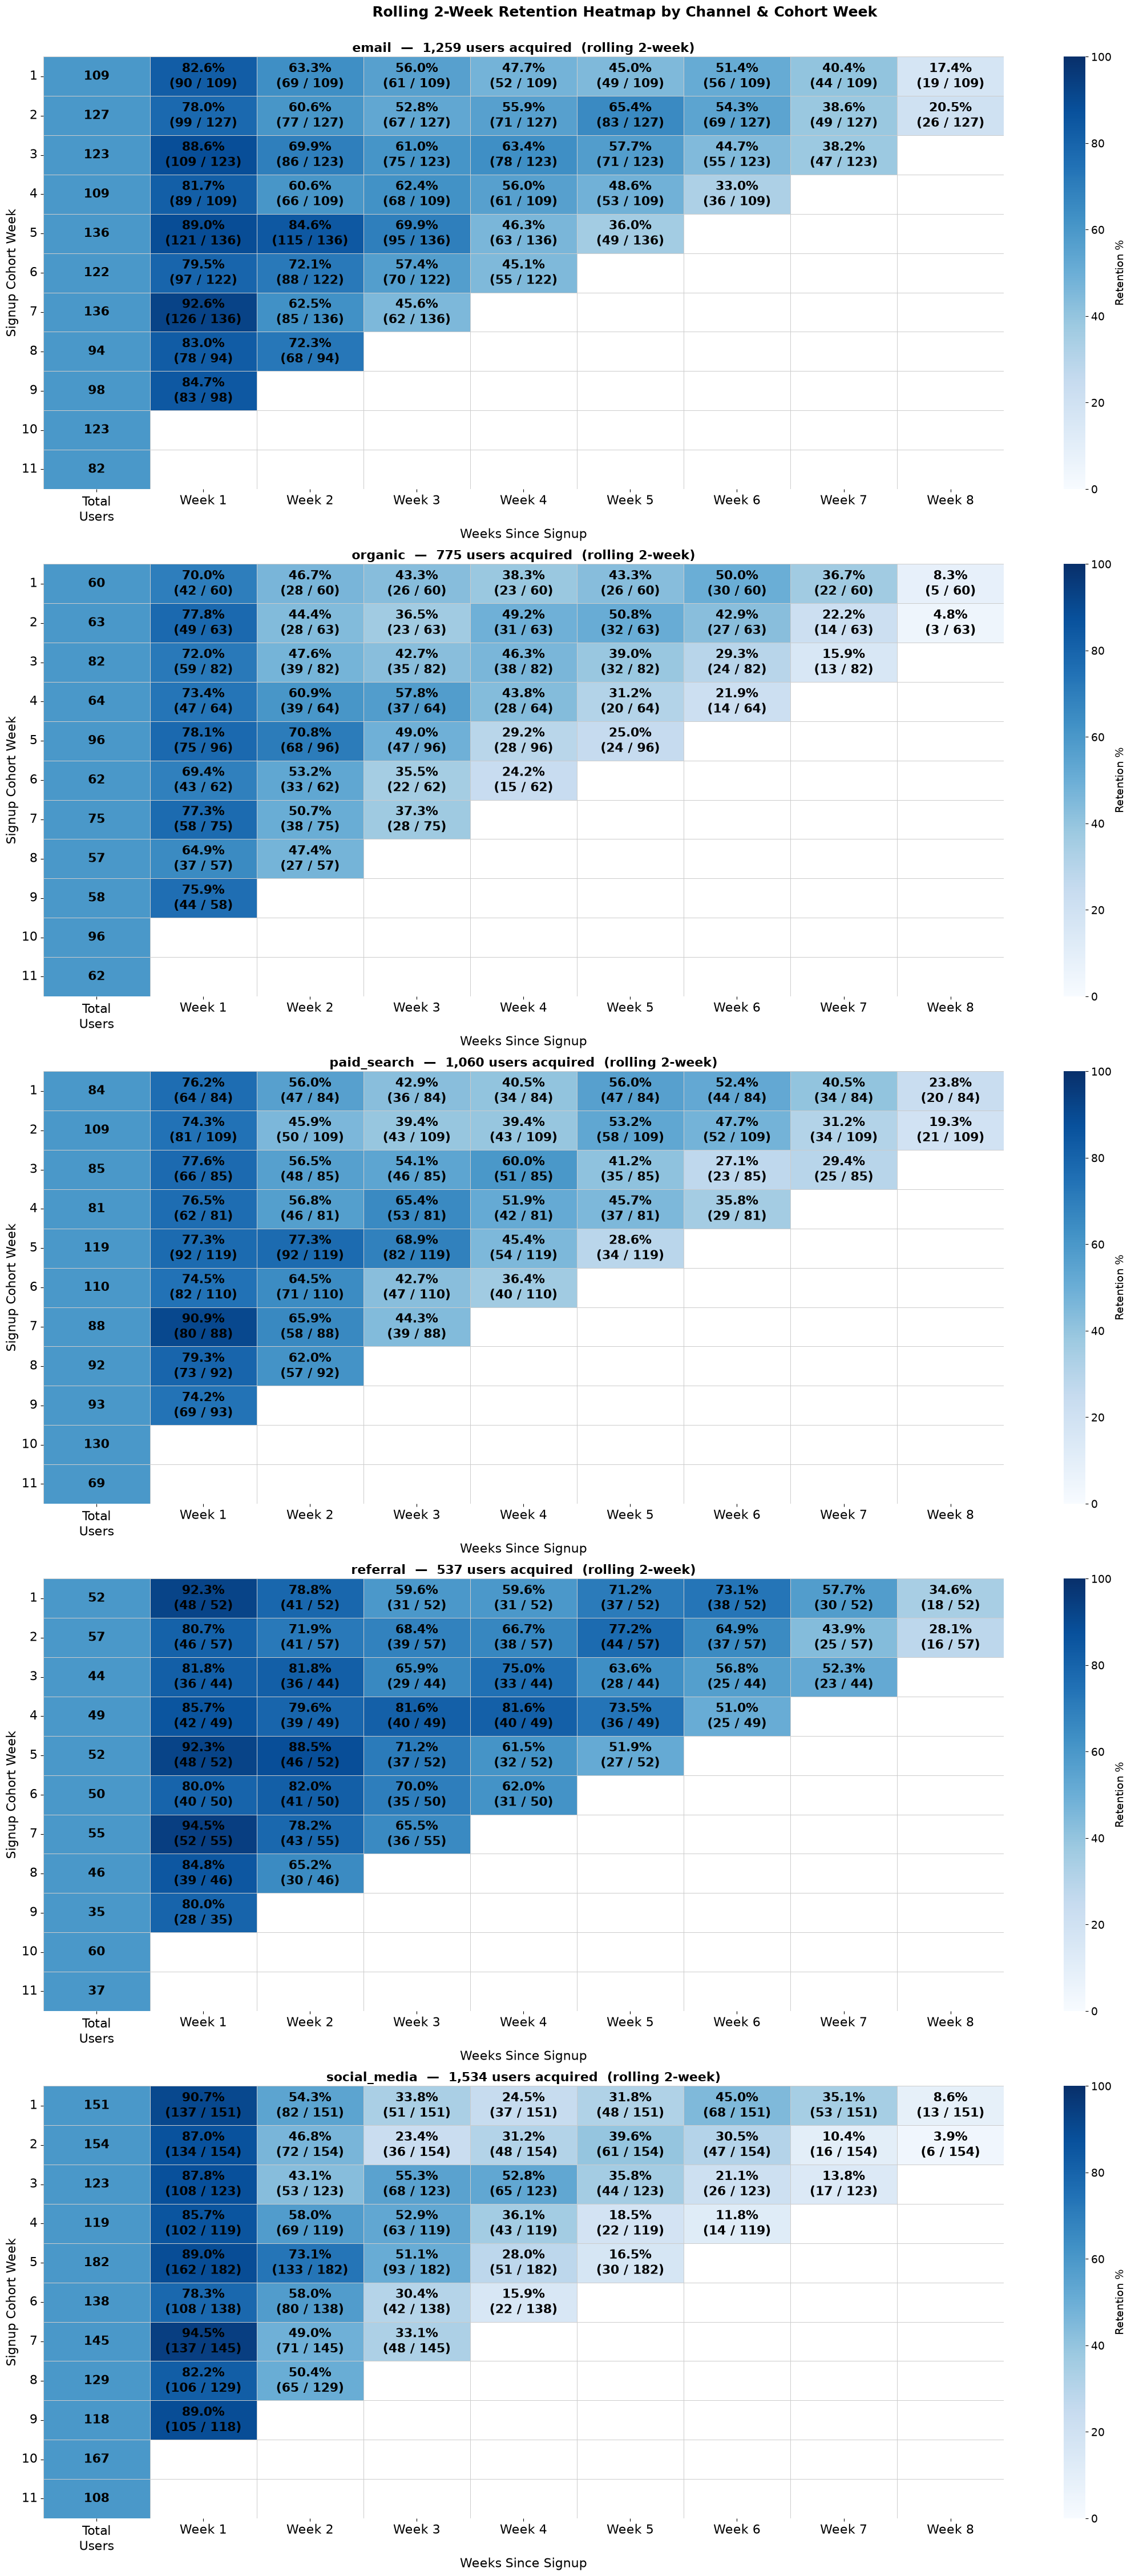

In [606]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ret_cols   = [f'w{i}_ret'  for i in range(1, 9)]
elig_cols  = [f'w{i}_elig' for i in range(1, 9)]
col_labels = [f'Week {i}' for i in range(1, 9)]
channels   = sorted(rolling_channel['acquisition_channel'].unique())
channel_volume = rolling_channel.groupby('acquisition_channel')['total_users'].sum()

fig, axes = plt.subplots(len(channels), 1, figsize=(22, 9 * len(channels)), facecolor='white')

for ax, channel in zip(axes, channels):
    sub     = rolling_channel[rolling_channel['acquisition_channel'] == channel].set_index('cohort_week')
    elig    = sub[elig_cols].replace(0, float('nan'))
    pct     = (sub[ret_cols].values / elig.values * 100).round(1)
    raw     = sub[ret_cols].values
    elg     = elig.values
    totals  = sub['total_users'].values
    cohorts = sub.index.tolist()

    pct_df = pd.DataFrame(pct, index=cohorts, columns=col_labels)
    pct_df.insert(0, 'Total\nUsers', 60.0)
    all_cols = ['Total\nUsers'] + col_labels

    annot = pd.DataFrame('', index=cohorts, columns=all_cols)
    for r, cw in enumerate(cohorts):
        annot.loc[cw, 'Total\nUsers'] = str(int(totals[r]))
        for c, col in enumerate(col_labels):
            p = pct[r, c]
            n = raw[r, c]
            m = elg[r, c]
            if np.isnan(p) or np.isnan(m):
                annot.loc[cw, col] = ''
            else:
                annot.loc[cw, col] = f'{p:.1f}%\n({int(n)} / {int(m)})'

    ax.set_facecolor('white')
    sns.heatmap(
        pct_df, ax=ax, cmap='Blues', annot=annot, fmt='',
        linewidths=0.5, linecolor='#cccccc',
        annot_kws={'size': 16, 'color': 'black', 'fontweight': 'bold'},
        vmin=0, vmax=100,
        cbar_kws={'label': 'Retention %'}
    )

    total_vol = channel_volume[channel]
    ax.set_title(f'{channel}  —  {total_vol:,} users acquired  (rolling 2-week)',
                 fontsize=16, fontweight='bold', color='black')
    ax.set_xlabel('Weeks Since Signup', fontsize=16, color='black')
    ax.set_ylabel('Signup Cohort Week', fontsize=16, color='black')
    ax.set_xticklabels(all_cols, fontsize=16, color='black', rotation=0)
    ax.set_yticklabels(cohorts, rotation=0, fontsize=16, color='black')
    ax.tick_params(axis='both', colors='black')
    cbar = ax.collections[0].colorbar
    cbar.set_label('Retention %', fontsize=14, color='black')
    cbar.ax.tick_params(labelsize=14, colors='black')

plt.suptitle('Rolling 2-Week Retention Heatmap by Channel & Cohort Week',
             fontsize=18, fontweight='bold', color='black', y=1.002)
plt.tight_layout()
plt.show()

## Rolling 2-Week Retention by Channel & Cohort — Interpretation

---

### How to Read This Heatmap

- **Each subplot = one channel** — rows are cohort weeks, columns are weeks since signup
- **Cell value** = % of eligible users active in week N or week N+1 (rolling 2-week window)
- **Eligible denominator**: only users whose 2-week window fully elapsed before the Mar 15 snapshot — blank cells are unobservable, not zero
- **Total Users column** = raw users acquired in that cohort week — use it to weight findings (small cohorts = noisy)
- **Compare subplots side by side** to spot which channel retains best at the same cohort week

---

### Key Observations

#### 1. referral — best and most consistent long-term retention
Referral dominates across all cohort weeks. Week 1 rolling retention ranges from **80–94%** depending on cohort, and the decay is the slowest of all channels. Cohort 4 referral is the standout: **85.7% → 79.6% → 81.6% → 81.6%** through weeks 1–4 — barely decaying at all. These users have formed a genuine, stable workout habit.

**Why:** Referred users arrive with social accountability. Someone they trust recommended the app, creating external motivation that sustains engagement well past the initial novelty period.

#### 2. social_media — highest week 1, fastest collapse
Social_media week 1 rolling retention is among the highest across most cohorts (87–94%), but the decay is the steepest. By week 4, most cohorts are at 24–45% — significantly below referral and email at the same point. Cohort 7 social_media hits **94.5% at week 1** (tied highest with referral), but that cohort runs out of observable window before we can see how it decays.

**Why:** Social campaigns attract attention-driven signups — people who saw an ad and were curious. The rolling window is forgiving (catches users who try the app in week 1 or 2), which inflates the early numbers. But by week 4–5, the curiosity has worn off and they've genuinely churned.

#### 3. email — steady and reliable
Email week 1 rolling retention sits at **78–92%** across cohorts, with cohort 7 reaching 92.6%. The decay is gradual and consistent — email users don't spike early and crash; they engage steadily. This makes email the most predictable channel for forward-looking LTV estimates.

**Why:** Email subscribers opted in before downloading — that pre-commitment signals higher intent and filters out low-quality signups.

#### 4. paid_search — intent-driven but mid-tier
Paid search week 1 rolling retention is solid at **74–90%**, with cohort 7 spiking to 90.9%. Decay is moderate — better than social_media but below referral. Week 4–6 numbers are reasonable, suggesting paid search users have some habit formation, just not at the referral level.

**Why:** Search intent is real (users actively looked for a fitness app) but doesn't come with social accountability. Once the initial motivation fades, there's no external force pulling them back.

#### 5. organic — lowest but most cost-efficient
Organic consistently shows the lowest rolling retention (week 1: **69–78%**), but volume is smaller and CAC is near zero. The decay pattern is similar to paid_search but starting from a lower base. Not a red flag on its own — it's expected that discovery-driven users have lower intent.

---

### Cross-Cutting Observations

#### Mid-February bump — visible in ALL channels at weeks 5–6 (cohort 1)
Every channel shows a week 5–6 uptick for cohort 1 that breaks the expected decay:

| Channel | Week 4 | Week 5 | Week 6 |
|---|---|---|---|
| referral | 59.6% | 71.2% | 73.1% |
| email | 47.7% | 45.0% | 51.4% |
| paid_search | 40.5% | 56.0% | 52.4% |
| organic | 38.3% | 43.3% | 50.0% |
| social_media | 24.5% | 31.8% | 45.0% |

The bump appears at the same calendar date (mid-February) across all five channels — **this is a platform-wide event, not a channel-quality signal**. A campaign, feature release, or seasonal fitness spike re-engaged users across the board. It should be excluded from baseline retention projections unless the event is repeatable.

#### Cohort 6 (Feb 5 week) — operational anomaly confirmed across channels
Week 1 rolling retention for cohort 6 is lower than neighboring cohorts in every channel:

| Channel | Cohort 5 W1 | Cohort 6 W1 | Cohort 7 W1 |
|---|---|---|---|
| referral | 92.3% | 80.0% | 94.5% |
| email | 89.0% | 79.5% | 92.6% |
| social_media | 89.0% | 78.3% | 94.5% |
| paid_search | 77.3% | 74.5% | 90.9% |
| organic | 78.1% | 69.4% | 77.3% |

The dip is cohort-specific and cuts across all channels simultaneously — ruling out an acquisition-quality explanation. This points to an **operational issue that week** (bug, outage, broken onboarding flow) that affected all new users regardless of where they came from.

---

### Series B Framing

> *"Rolling retention confirms referral as the highest-quality acquisition channel — cohort 4 referral users hold above 80% rolling retention through week 4, a level no other channel approaches. The mid-February platform-wide engagement spike and the isolated cohort 6 dip are explainable anomalies that don't undermine the baseline story. Reallocating acquisition budget from social_media (highest volume, fastest decay) toward referral incentives and email nurture would improve both the LTV/CAC ratio and the retention curve we present to investors."*